### 3.1 Introducción

**Notebook 3 - Generación y Validación de Datos Sintéticos**

**Objetivo**

En este notebook se desarrolla la fase de generación y validación de datos sintéticos correspondiente a la metodología CRISP-DM.

A partir del conjunto de datos real preparado en la etapa anterior, se entrenarán y compararán diferentes modelos de síntesis de datos tabulares con el objetivo de identificar aquel que mejor preserve las características estadísticas del conjunto original, manteniendo al mismo tiempo un adecuado nivel de privacidad.

Los modelos evaluados serán:

- Gaussian Copula
- TVAE (Tabular Variational Autoencoder)
- CTGAN (Conditional Tabular GAN)

La comparación se realizará mediante métricas de calidad estadística, preservación de relaciones entre variables, privacidad y capacidad para generar conjuntos de datos aptos para el entrenamiento de modelos de estimación de Probabilidad de Default (PD).

Finalmente, el mejor modelo será utilizado para generar un conjunto de datos sintético equivalente al tamaño del dataset original y un conjunto ampliado de 500 000 registros para evaluar la escalabilidad del enfoque.

### 3.2 Carga del dataset preparado

In [ ]:
#Librerias
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
#Leer desde drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ruta del dataset preparado
ruta = "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/02_Data_Preparation/dataset_real_final.parquet"

df_real = pd.read_parquet(ruta)

df_real.head()

,TARGET,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_REQ_CREDIT_BUREAU_YEAR,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,CODE_GENDER,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS,NAME_EDUCATION_TYPE,NAME_HOUSING_TYPE,DAYS_EMPLOYED,NAME_INCOME_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,OWN_CAR_AGE,FLAG_OWN_REALTY,NAME_CONTRACT_TYPE,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,AGE,EMPLOYMENT_YEARS,HAS_CAR_AGE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_FAMILY,CHILDREN_RATIO,CREDIT_TERM_EST
0,1,100002,202500.0,406597.5,24700.5,351000.0,1.0,2.0,2.0,2.0,2.0,0.083037,0.262949,0.139376,-9461,M,0,1.0,Single / not married,Secondary / secondary special,House / apartment,-637.0,Working,Laborers,Business Entity Type 3,N,9.0,Y,Cash loans,Unaccompanied,WEDNESDAY,10,25.9,1.7,0,2.007889,0.121978,1.158397,202500.0,0.0,16.461104
1,0,100003,270000.0,1293502.5,35698.5,1129500.0,0.0,1.0,0.0,1.0,0.0,0.311267,0.622246,0.535276,-16765,F,0,2.0,Married,Higher education,House / apartment,-1188.0,State servant,Core staff,School,N,9.0,N,Cash loans,Family,MONDAY,11,45.9,3.3,0,4.790750,0.132217,1.145199,135000.0,0.0,36.234085
2,0,100004,67500.0,135000.0,6750.0,135000.0,0.0,0.0,0.0,0.0,0.0,0.505998,0.555912,0.729567,-19046,M,0,1.0,Single / not married,Secondary / secondary special,House / apartment,-225.0,Working,Laborers,Government,Y,26.0,Y,Revolving loans,Unaccompanied,MONDAY,9,52.1,0.6,1,2.000000,0.100000,1.000000,67500.0,0.0,20.000000
3,0,100006,135000.0,312682.5,29686.5,297000.0,1.0,2.0,0.0,2.0,0.0,0.505998,0.650442,0.535276,-19005,F,0,2.0,Civil marriage,Secondary / secondary special,House / apartment,-3039.0,Working,Laborers,Business Entity Type 3,N,9.0,Y,Cash loans,Unaccompanied,WEDNESDAY,17,52.0,8.3,0,2.316167,0.219900,1.052803,67500.0,0.0,10.532818
4,0,100007,121500.0,513000.0,21865.5,513000.0,0.0,0.0,0.0,0.0,0.0,0.505998,0.322738,0.535276,-19932,M,0,1.0,Single / not married,Secondary / secondary special,House / apartment,-3038.0,Working,Core staff,Religion,N,9.0,Y,Cash loans,Unaccompanied,THURSDAY,11,54.6,8.3,0,4.222222,0.179963,1.000000,121500.0,0.0,23.461618


In [ ]:
#Dimensiones
print("="*60)
print("DATASET PREPARADO")
print("="*60)

print(f"Número de registros : {df_real.shape[0]:,}")
print(f"Número de variables : {df_real.shape[1]}")

DATASET PREPARADO
Número de registros : 307,507
Número de variables : 41


In [ ]:
#Tipos de datos
df_real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307507 entries, 0 to 307506
Data columns (total 41 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      307507 non-null  int64  
 1   SK_ID_CURR                  307507 non-null  int64  
 2   AMT_INCOME_TOTAL            307507 non-null  float64
 3   AMT_CREDIT                  307507 non-null  float64
 4   AMT_ANNUITY                 307507 non-null  float64
 5   AMT_GOODS_PRICE             307507 non-null  float64
 6   AMT_REQ_CREDIT_BUREAU_YEAR  307507 non-null  float64
 7   OBS_30_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 8   DEF_30_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 9   OBS_60_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 10  DEF_60_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 11  EXT_SOURCE_1                307507 non-null  float64
 12  EXT_SOURCE_2                307507 non-null  float64
 13  EXT_SOURCE_3  

In [ ]:
#Resumen estadistico
df_real.describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET,307507.0,0.080730,0.272420,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
SK_ID_CURR,307507.0,278181.527256,102790.132982,1.000020e+05,189146.500000,278203.000000,367143.500000,4.562550e+05
AMT_INCOME_TOTAL,307507.0,168797.685779,237124.627320,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307507.0,599028.596733,402492.601859,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307507.0,27108.580714,14493.522125,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307507.0,538317.809016,369289.766071,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
AMT_REQ_CREDIT_BUREAU_YEAR,307507.0,1.778441,1.765512,0.000000e+00,1.000000,1.000000,3.000000,2.500000e+01
OBS_30_CNT_SOCIAL_CIRCLE,307507.0,1.417486,2.398337,0.000000e+00,0.000000,0.000000,2.000000,3.480000e+02
DEF_30_CNT_SOCIAL_CIRCLE,307507.0,0.142930,0.445978,0.000000e+00,0.000000,0.000000,0.000000,3.400000e+01
OBS_60_CNT_SOCIAL_CIRCLE,307507.0,1.400589,2.377165,0.000000e+00,0.000000,0.000000,2.000000,3.440000e+02


### 3.3 Preparación para los modelos generativos

#### 3.3.1 Caracterización del dataset

In [ ]:
#Clasificación automática de variables
# Variables numéricas

numeric_columns = df_real.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Variables categóricas

categorical_columns = df_real.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Variables booleanas

boolean_columns = df_real.select_dtypes(
    include=["bool"]
).columns.tolist()

print(f"Variables numéricas   : {len(numeric_columns)}")
print(f"Variables categóricas : {len(categorical_columns)}")
print(f"Variables booleanas   : {len(boolean_columns)}")

Variables numéricas   : 29
Variables categóricas : 12
Variables booleanas   : 0


In [ ]:
# Variables binarias
binary_columns = []

for col in df_real.columns:

    if df_real[col].nunique() == 2:

        valores = sorted(df_real[col].dropna().unique())

        if valores == [0,1] or valores == [0.0,1.0]:

            binary_columns.append(col)

print(f"Variables binarias (0-1): {len(binary_columns)}")

binary_columns

Variables binarias (0-1): 2


['TARGET', 'HAS_CAR_AGE']

In [ ]:
# Resumen general
summary = pd.DataFrame({

    "Tipo de variable":[
        "Numéricas",
        "Categóricas",
        "Booleanas",
        "Binarias (0-1)"
    ],

    "Cantidad":[
        len(numeric_columns),
        len(categorical_columns),
        len(boolean_columns),
        len(binary_columns)
    ]

})

summary

,Tipo de variable,Cantidad
0,Numéricas,29
1,Categóricas,12
2,Booleanas,0
3,Binarias (0-1),2


In [ ]:
# Numero de categorias
if len(categorical_columns) > 0:

    categorias = pd.DataFrame({

        "Variable": categorical_columns,

        "Categorías":
        [df_real[col].nunique() for col in categorical_columns]

    })

    categorias.sort_values(
        by="Categorías",
        ascending=False
    )

else:

    print("No existen variables categóricas.")

In [ ]:
# Distribucion de tipos de datos
tipos = pd.DataFrame(

    df_real.dtypes.value_counts()

).reset_index()

tipos.columns=["Tipo","Cantidad"]

tipos

,Tipo,Cantidad
0,float64,23
1,object,12
2,int64,6


#### 3.3.2 Construcción del Metadata

**5.3.2 Construcción del Metadata**

Los modelos generativos implementados en SDV requieren una descripción explícita de la estructura del conjunto de datos. Esta descripción se almacena en un objeto denominado **Metadata**, el cual especifica el tipo semántico de cada variable (numérica, categórica, booleana, identificador, entre otras).

El uso del Metadata garantiza que los modelos generativos aprendan adecuadamente las distribuciones y relaciones existentes entre las variables, evitando interpretaciones incorrectas durante el proceso de síntesis.

Antes de entrenar los modelos Gaussian Copula, TVAE y CTGAN, se construirá e inspeccionará el Metadata para verificar que la representación del conjunto de datos sea consistente con su estructura real.

In [ ]:
# Instalar SDV
!pip install -q sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.9/209.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.0/207.0 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 8.2 MB/s eta 0:00:00


In [ ]:
#Importar librerias
from sdv.metadata import SingleTableMetadata

In [ ]:
# Construccion automatica del metadata
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(df_real)

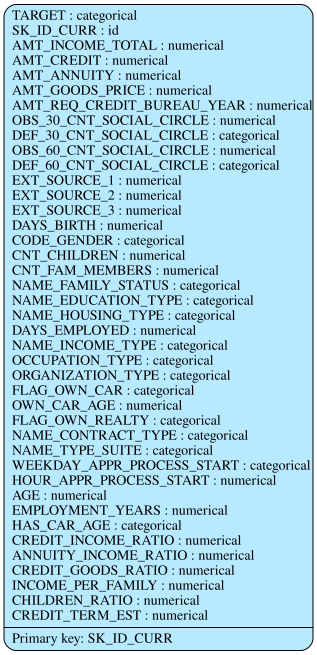

In [ ]:
# Visualizar Metadata
metadata.visualize()

In [ ]:
# Convertir el metadata en un diccionario
metadata_dict = metadata.to_dict()

metadata_dict.keys()

dict_keys(['primary_key', 'columns', 'METADATA_SPEC_VERSION'])

In [ ]:
# Revisar las columnas detectadas
metadata_dict

{'primary_key': 'SK_ID_CURR',
 'columns': {'TARGET': {'sdtype': 'categorical'},
  'SK_ID_CURR': {'sdtype': 'id'},
  'AMT_INCOME_TOTAL': {'sdtype': 'numerical'},
  'AMT_CREDIT': {'sdtype': 'numerical'},
  'AMT_ANNUITY': {'sdtype': 'numerical'},
  'AMT_GOODS_PRICE': {'sdtype': 'numerical'},
  'AMT_REQ_CREDIT_BUREAU_YEAR': {'sdtype': 'numerical'},
  'OBS_30_CNT_SOCIAL_CIRCLE': {'sdtype': 'numerical'},
  'DEF_30_CNT_SOCIAL_CIRCLE': {'sdtype': 'categorical'},
  'OBS_60_CNT_SOCIAL_CIRCLE': {'sdtype': 'numerical'},
  'DEF_60_CNT_SOCIAL_CIRCLE': {'sdtype': 'categorical'},
  'EXT_SOURCE_1': {'sdtype': 'numerical'},
  'EXT_SOURCE_2': {'sdtype': 'numerical'},
  'EXT_SOURCE_3': {'sdtype': 'numerical'},
  'DAYS_BIRTH': {'sdtype': 'numerical'},
  'CODE_GENDER': {'sdtype': 'categorical'},
  'CNT_CHILDREN': {'sdtype': 'numerical'},
  'CNT_FAM_MEMBERS': {'sdtype': 'numerical'},
  'NAME_FAMILY_STATUS': {'sdtype': 'categorical'},
  'NAME_EDUCATION_TYPE': {'sdtype': 'categorical'},
  'NAME_HOUSING_TYPE': 

In [ ]:
# Crear un DataFrame con el Metadata
column_info = []

for column, info in metadata.columns.items():

    column_info.append({

        "Variable": column,
        "SDV Type": info["sdtype"]

    })

metadata_df = pd.DataFrame(column_info)

metadata_df.head(20)

,Variable,SDV Type
0,TARGET,categorical
1,SK_ID_CURR,id
2,AMT_INCOME_TOTAL,numerical
3,AMT_CREDIT,numerical
4,AMT_ANNUITY,numerical
5,AMT_GOODS_PRICE,numerical
6,AMT_REQ_CREDIT_BUREAU_YEAR,numerical
7,OBS_30_CNT_SOCIAL_CIRCLE,numerical
8,DEF_30_CNT_SOCIAL_CIRCLE,categorical
9,OBS_60_CNT_SOCIAL_CIRCLE,numerical


In [ ]:
# Resumen por tipo
metadata_df["SDV Type"].value_counts()

,count
SDV Type,
numerical,24
categorical,16
id,1


In [ ]:
# Verificar TARGET
metadata_df.loc[
    metadata_df["Variable"]=="TARGET"
]

,Variable,SDV Type
0,TARGET,categorical


In [ ]:
#Guardar metadata
#metadata.save_to_json(
#    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/03_Syntetic_Data/metadata_home_credit.json"
#)

#### 3.3.3 Verificación de consistencia

In [ ]:
#Dimensiones
print("Número de registros:", df_real.shape[0])
print("Número de variables:", df_real.shape[1])

Número de registros: 307507
Número de variables: 41


In [ ]:
#Tipos de datos
df_real.dtypes.value_counts()

,count
float64,23
object,12
int64,6


In [ ]:
#Missing values
missing = (
    df_real.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing.head(15)

,0
TARGET,0
SK_ID_CURR,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,0
AMT_GOODS_PRICE,0
AMT_REQ_CREDIT_BUREAU_YEAR,0
OBS_30_CNT_SOCIAL_CIRCLE,0
DEF_30_CNT_SOCIAL_CIRCLE,0
OBS_60_CNT_SOCIAL_CIRCLE,0


In [ ]:
#Duplicados
print(df_real.duplicated().sum())

0


In [ ]:
#Balance de target
df_real["TARGET"].value_counts(normalize=True)*100

,proportion
TARGET,
0,91.927013
1,8.072987


In [ ]:
num_cols = df_real.select_dtypes(include=["int64","float64"]).shape[1]

cat_cols = df_real.select_dtypes(include=["object","category"]).shape[1]

In [ ]:
consistencia = pd.DataFrame({

    "Verificación":[
        "Valores faltantes",
        "Duplicados",
        "Primary Key",
        "Variables numéricas",
        "Variables categóricas",
        "Target"
    ],

    "Resultado":[

        df_real.isnull().sum().sum(),

        df_real.duplicated().sum(),

        "SK_ID_CURR",

        num_cols,

        cat_cols,

        "TARGET"

    ]

})

consistencia

,Verificación,Resultado
0,Valores faltantes,0
1,Duplicados,0
2,Primary Key,SK_ID_CURR
3,Variables numéricas,29
4,Variables categóricas,12
5,Target,TARGET


### 3.4 Entrenamiento de modelos generativos

**5.4 Construcción del conjunto experimental**

Con el propósito de comparar distintos modelos generativos de manera eficiente desde el punto de vista computacional, se construyó un subconjunto experimental estratificado de 20 000 registros.

El muestreo estratificado garantiza la conservación de la distribución original de la variable objetivo (TARGET), permitiendo evaluar los sintetizadores sobre un conjunto representativo sin comprometer la validez de los resultados experimentales.

El conjunto completo de datos se reservará posteriormente para la generación definitiva del dataset sintético.

In [ ]:
#Muestre estratificado
from sklearn.model_selection import train_test_split

df_experiment, _ = train_test_split(
    df_real,
    train_size=20000,
    stratify=df_real["TARGET"],
    random_state=42
)

In [ ]:
#Verificacion
print(df_experiment.shape)

df_experiment["TARGET"].value_counts(normalize=True) * 100

(20000, 41)


,proportion
TARGET,
0,91.925
1,8.075


In [ ]:
#Comparacion
comparacion = pd.DataFrame({

    "Dataset completo (%)":
        df_real["TARGET"]
        .value_counts(normalize=True)
        .sort_index()*100,

    "Dataset experimental (%)":
        df_experiment["TARGET"]
        .value_counts(normalize=True)
        .sort_index()*100

})

comparacion

,Dataset completo (%),Dataset experimental (%)
TARGET,,
0,91.927013,91.925
1,8.072987,8.075


#### 3.4.1 Gaussian Copula

**5.4.1 Gaussian Copula**

Como primer método de síntesis se empleó Gaussian Copula, un modelo probabilístico que aproxima la distribución conjunta de las variables mediante una cópula gaussiana.

Este método constituye una línea base ampliamente utilizada en generación de datos sintéticos debido a su bajo coste computacional y su capacidad para preservar dependencias estadísticas entre variables.

In [ ]:
#Importar sintetizador
from sdv.single_table import GaussianCopulaSynthesizer

gc_synthesizer = GaussianCopulaSynthesizer(metadata)

In [ ]:
#Medicion de tiempo
import time

inicio = time.time()

gc_synthesizer.fit(df_experiment)

tiempo_gc = time.time() - inicio

print(f"Tiempo entrenamiento: {tiempo_gc:.2f} segundos")

Tiempo entrenamiento: 27.99 segundos


In [ ]:
#Generar un muestra
gc_sample = gc_synthesizer.sample(5000)

In [ ]:
def comparar_target(df_real, df_sintetico, nombre_modelo):

    comparacion = pd.DataFrame({
        "Real (%)":
            df_real["TARGET"]
            .value_counts(normalize=True)
            .sort_index()
            *100,

        f"{nombre_modelo} (%)":
            df_sintetico["TARGET"]
            .value_counts(normalize=True)
            .sort_index()
            *100
    })

    comparacion["Error (%)"] = (
        comparacion.iloc[:,0] -
        comparacion.iloc[:,1]
    ).abs()

    return comparacion

In [ ]:
#Comparacion del TARGET
comparar_target(
    df_experiment,
    gc_sample,
    "Gaussian Copula"
)

,Real (%),Gaussian Copula (%),Error (%)
TARGET,,,
0,91.925,91.7,0.225
1,8.075,8.3,0.225


In [ ]:
#Guardar
#gc_synthesizer.save(
#"/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/03_Syntetic_Data/modelos/gaussian_copula.pkl"
#)

#### 3.4.2 Generación mediante TVAE

**5.4.2 Generación mediante TVAE**

El segundo modelo evaluado corresponde a **Tabular Variational AutoEncoder (TVAE)**, un modelo generativo basado en redes neuronales profundas diseñado para aprender una representación latente de datos tabulares.

A diferencia de los modelos probabilísticos tradicionales, TVAE es capaz de capturar relaciones no lineales entre variables numéricas y categóricas mediante un proceso de codificación y decodificación.

En esta fase experimental se emplea una configuración base con un número moderado de épocas, con el objetivo de comparar su desempeño frente a los demás sintetizadores bajo condiciones computacionales equivalentes. La optimización de hiperparámetros se realizará únicamente sobre el modelo seleccionado como el mejor candidato.

In [ ]:
#Inicializar el modelo
from sdv.single_table import TVAESynthesizer

tvae_synthesizer = TVAESynthesizer(

    metadata=metadata,

    epochs=50,

    batch_size=500,

    verbose=True

)

In [ ]:
#Entrenamiento y medicion de tiempo
import time

inicio = time.time()

tvae_synthesizer.fit(df_experiment)

tiempo_tvae = time.time() - inicio

print(f"Tiempo de entrenamiento: {tiempo_tvae:.2f} segundos")

Loss: +19.31: 100%|██████████| 50/50 [01:26<00:00,  1.74s/it]

Tiempo de entrenamiento: 209.72 segundos


In [ ]:
#Informacion del modelo
print(tvae_synthesizer)

In [ ]:
#Generar muestra sintetica
df_tvae_sample = tvae_synthesizer.sample(5000)

df_tvae_sample.head()

,TARGET,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_REQ_CREDIT_BUREAU_YEAR,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,CODE_GENDER,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS,NAME_EDUCATION_TYPE,NAME_HOUSING_TYPE,DAYS_EMPLOYED,NAME_INCOME_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,OWN_CAR_AGE,FLAG_OWN_REALTY,NAME_CONTRACT_TYPE,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,AGE,EMPLOYMENT_YEARS,HAS_CAR_AGE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_FAMILY,CHILDREN_RATIO,CREDIT_TERM_EST
0,0,2911027,112134.685,529880.4,21280.9,536029.3,1.0,0.0,0.0,0.0,0.0,0.505918,0.620052,0.531624,-17713,F,0,2.0,Married,Secondary / secondary special,House / apartment,-1404.0,Working,Laborers,Business Entity Type 3,N,9.0,Y,Cash loans,Unaccompanied,MONDAY,11,46.1,6.3,0,4.127736,0.203857,0.997968,58039.632173,0.000141,21.718952
1,0,12424021,466080.393,831734.0,40573.1,519868.5,1.0,1.0,0.0,1.0,0.0,0.506097,0.692162,0.462100,-12975,F,0,2.0,Married,Higher education,House / apartment,-2349.0,Working,Managers,Business Entity Type 3,Y,9.0,Y,Cash loans,Unaccompanied,WEDNESDAY,16,37.6,7.1,1,2.307185,0.096324,0.998669,178867.238010,0.000201,19.795505
2,0,13751962,73194.469,446238.3,21241.9,401459.5,1.0,0.0,0.0,0.0,0.0,0.506793,0.703677,0.533543,-16907,F,1,3.0,Married,Secondary / secondary special,House / apartment,-1642.0,Working,Laborers,XNA,Y,12.0,Y,Cash loans,Unaccompanied,WEDNESDAY,10,49.7,4.4,1,5.722948,0.255468,1.118928,19929.242999,0.332505,20.617611
3,0,3926314,72405.318,82746.9,5333.0,138480.5,1.0,0.0,0.0,0.0,0.0,0.506182,0.734063,0.536986,-17519,F,0,2.0,Married,Secondary / secondary special,House / apartment,-1605.0,Working,Laborers,Business Entity Type 3,N,9.0,Y,Cash loans,Unaccompanied,WEDNESDAY,10,44.5,4.3,0,1.288230,0.143289,0.999492,21313.031858,0.000034,8.545001
4,0,777268,210996.343,835495.2,30154.0,667215.4,1.0,0.0,0.0,0.0,0.0,0.505557,0.710470,0.539934,-21333,F,0,1.0,Single / not married,Secondary / secondary special,House / apartment,-1778.0,Working,Laborers,Business Entity Type 3,N,9.0,Y,Cash loans,Unaccompanied,WEDNESDAY,16,50.1,3.8,0,2.713388,0.127547,1.110681,262102.430856,0.000000,27.497533


In [ ]:
#Comparación del TARGET
comparar_target(

    df_experiment,

    df_tvae_sample,

    "TVAE"

)

,Real (%),TVAE (%),Error (%)
TARGET,,,
0,91.925,100.0,8.075
1,8.075,NaN,NaN


In [ ]:
#Comparacion descriptiva de variables
variables_revision = [

    "AMT_INCOME_TOTAL",

    "AMT_CREDIT",

    "AMT_ANNUITY",

    "EXT_SOURCE_2",

    "AGE"

]

comparacion = pd.DataFrame({

    "Media Real": df_experiment[variables_revision].mean(),

    "Media TVAE": df_tvae_sample[variables_revision].mean(),

    "Std Real": df_experiment[variables_revision].std(),

    "Std TVAE": df_tvae_sample[variables_revision].std()

})

comparacion.round(2)

,Media Real,Media TVAE,Std Real,Std TVAE
AMT_INCOME_TOTAL,168013.45,148776.61,97666.50,70752.84
AMT_CREDIT,597415.02,572022.16,401174.02,358881.80
AMT_ANNUITY,27032.17,23984.81,14515.58,10601.02
EXT_SOURCE_2,0.51,0.66,0.19,0.06
AGE,43.89,44.32,11.95,12.24


In [ ]:
#Guardar
#tvae_synthesizer.save(
#
#"/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/03_Syntetic_Data/modelos/tvae_synthesizer.pkl"
#
#)

#### 3.4.3 Generación mediante CTGAN

**5.4.3 Generación mediante CTGAN**

El tercer modelo evaluado corresponde a **Conditional Tabular Generative Adversarial Network (CTGAN)**, una arquitectura basada en Redes Generativas Antagónicas (GAN) diseñada específicamente para la síntesis de datos tabulares.

CTGAN incorpora un mecanismo de entrenamiento condicional que permite modelar de manera más precisa variables categóricas y distribuciones complejas presentes en problemas de riesgo crediticio.

Al igual que los demás sintetizadores, en esta etapa se utiliza una configuración base orientada a la comparación experimental. La optimización de hiperparámetros únicamente se realizará sobre el modelo finalmente seleccionado.

In [ ]:
from sdv.single_table import CTGANSynthesizer

In [ ]:
#Aplicando configuracion moderada
ctgan_synthesizer = CTGANSynthesizer(

    metadata=metadata,

    epochs=50,

    batch_size=500,

    pac=1,

    verbose=True

)

In [ ]:
#Midiendo tiempo de entrenamiento:
import time

inicio = time.time()

ctgan_synthesizer.fit(df_experiment)

tiempo_ctgan = time.time() - inicio

print(f"Tiempo entrenamiento: {tiempo_ctgan:.2f} segundos")

Gen. (+00.14) | Discrim. (-00.46): 100%|██████████| 50/50 [08:19<00:00,  9.99s/it]

Tiempo entrenamiento: 610.58 segundos


In [ ]:
print(ctgan_synthesizer)

In [ ]:
#Gnerando una muestra
df_ctgan_sample = ctgan_synthesizer.sample(5000)

df_ctgan_sample.head()

,TARGET,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_REQ_CREDIT_BUREAU_YEAR,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,CODE_GENDER,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS,NAME_EDUCATION_TYPE,NAME_HOUSING_TYPE,DAYS_EMPLOYED,NAME_INCOME_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,OWN_CAR_AGE,FLAG_OWN_REALTY,NAME_CONTRACT_TYPE,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,AGE,EMPLOYMENT_YEARS,HAS_CAR_AGE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_FAMILY,CHILDREN_RATIO,CREDIT_TERM_EST
0,0,2911027,310313.650,596861.7,21888.8,452446.5,0.0,0.0,0.0,0.0,0.0,0.504589,0.372700,0.651862,-19053,F,0,1.0,Married,Secondary / secondary special,House / apartment,-1686.0,Pensioner,Laborers,Trade: type 7,Y,19.0,Y,Cash loans,Unaccompanied,WEDNESDAY,12,56.1,4.6,1,4.823024,0.123482,0.998912,117557.468189,0.000659,30.826186
1,0,12424021,271160.431,323400.9,13704.4,249630.9,0.0,0.0,0.0,2.0,0.0,0.504254,0.599757,0.537404,-22487,M,0,2.0,Married,Secondary / secondary special,House / apartment,-998.0,Commercial associate,Cooking staff,Business Entity Type 3,Y,13.0,Y,Cash loans,Unaccompanied,MONDAY,14,34.6,2.7,1,1.610608,0.077455,0.998632,105215.659083,0.001834,18.735926
2,0,13751962,130620.284,230805.1,9963.5,268904.6,0.0,0.0,0.0,0.0,0.0,0.178389,0.219297,0.371373,-16683,F,2,4.0,Married,Secondary / secondary special,House / apartment,-779.0,Commercial associate,Core staff,Business Entity Type 3,N,9.0,Y,Revolving loans,Other_B,WEDNESDAY,20,32.2,1.4,0,2.119344,0.072303,0.999376,51721.262846,0.337193,16.128167
3,1,3926314,79945.880,230149.6,20579.3,233516.4,0.0,0.0,0.0,0.0,0.0,0.506095,0.177720,0.435921,-13838,F,0,2.0,Married,Secondary / secondary special,House / apartment,-7149.0,State servant,Laborers,Self-employed,N,9.0,N,Cash loans,Unaccompanied,SATURDAY,10,26.1,6.1,0,3.140626,0.129471,0.997456,108980.874804,0.001671,20.955058
4,0,777268,169882.103,132987.4,9248.9,142451.6,0.0,0.0,0.0,0.0,0.0,0.505778,0.625548,0.812887,-11596,F,0,2.0,Married,Secondary / secondary special,House / apartment,-2583.0,State servant,Cooking staff,Business Entity Type 3,N,9.0,N,Revolving loans,Unaccompanied,MONDAY,10,36.1,6.5,0,2.563171,0.113667,1.086955,74790.889595,0.000607,10.551375


In [ ]:
#Generacion de TARGET
comparar_target(

    df_experiment,

    df_ctgan_sample,

    "CTGAN"

)

,Real (%),CTGAN (%),Error (%)
TARGET,,,
0,91.925,92.4,0.475
1,8.075,7.6,0.475


In [ ]:
#Comparacion descriptiva
variables_revision = [

    "AMT_INCOME_TOTAL",

    "AMT_CREDIT",

    "AMT_ANNUITY",

    "EXT_SOURCE_2",

    "AGE"

]

comparacion = pd.DataFrame({

    "Media Real": df_experiment[variables_revision].mean(),

    "Media CTGAN": df_ctgan_sample[variables_revision].mean(),

    "Std Real": df_experiment[variables_revision].std(),

    "Std CTGAN": df_ctgan_sample[variables_revision].std()

})

comparacion.round(2)

,Media Real,Media CTGAN,Std Real,Std CTGAN
AMT_INCOME_TOTAL,168013.45,164491.63,97666.50,85607.44
AMT_CREDIT,597415.02,627497.66,401174.02,416523.12
AMT_ANNUITY,27032.17,25778.25,14515.58,13208.82
EXT_SOURCE_2,0.51,0.46,0.19,0.19
AGE,43.89,42.09,11.95,12.10


In [ ]:
#Guardar modelo
#ctgan_synthesizer.save(
#
#"/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/03_Syntetic_Data/modelos/ctgan_synthesizer.pkl"
#
#)

### 3.5 Comparación experimental de los sintetizadores

**5.5 Evaluación preliminar de los modelos generativos**

Como parte de la evaluación inicial, se verificó la capacidad de cada modelo para preservar la distribución de la variable objetivo (TARGET), la cual representa el incumplimiento crediticio.

Esta verificación resulta especialmente relevante debido al fuerte desbalance del conjunto Home Credit, donde aproximadamente el 92% de las observaciones corresponden a clientes sin incumplimiento y únicamente el 8% representan casos de default.

La preservación adecuada de dicha distribución es un requisito indispensable para entrenar posteriormente modelos de estimación de Probabilidad de Default (PD) utilizando exclusivamente datos sintéticos.

#### 3.5.1 Evaluación de la variable objetivo (TARGET)

Objetivo

Evaluar si los modelos generativos mantienen la distribución de la variable objetivo (TARGET) respecto al conjunto de datos real.

En credit scoring esto es fundamental porque un sintetizador que modifica significativamente la tasa de incumplimiento introduce un sesgo importante en los modelos posteriores de estimación de PD.

In [ ]:
def comparar_target(df_real, df_sintetico, nombre):

    real = (
        df_real["TARGET"]
        .value_counts(normalize=True)
        .sort_index()*100
    )

    sintetico = (
        df_sintetico["TARGET"]
        .value_counts(normalize=True)
        .sort_index()*100
    )

    comparacion = pd.DataFrame({
        "Real (%)": real,
        nombre: sintetico
    })

    comparacion["Error (%)"] = (
        comparacion["Real (%)"] -
        comparacion[nombre]
    ).abs()

    return comparacion

In [ ]:
gc_target = comparar_target(
    df_real,
    gc_sample,
    "Gaussian Copula"
)

gc_target

,Real (%),Gaussian Copula,Error (%)
TARGET,,,
0,91.927013,91.7,0.227013
1,8.072987,8.3,0.227013


In [ ]:
tvae_target = comparar_target(
    df_real,
    df_tvae_sample,
    "TVAE"
)
tvae_target

,Real (%),TVAE,Error (%)
TARGET,,,
0,91.927013,100.0,8.072987
1,8.072987,NaN,NaN


In [ ]:
ctgan_target = comparar_target(
    df_real,
    df_ctgan_sample,
    "CTGAN"
)
ctgan_target

,Real (%),CTGAN,Error (%)
TARGET,,,
0,91.927013,92.4,0.472987
1,8.072987,7.6,0.472987


In [ ]:
#Reunimos el error de los 3 modelos
target_scores = pd.DataFrame({

    "Modelo":[
        "Gaussian Copula",
        "TVAE",
        "CTGAN"
    ],

    "Error TARGET (%)":[

        gc_target["Error (%)"].mean(),
        tvae_target["Error (%)"].mean(),
        ctgan_target["Error (%)"].mean()

    ]

})

target_scores.sort_values(
    "Error TARGET (%)"
)

,Modelo,Error TARGET (%)
0,Gaussian Copula,0.227013
2,CTGAN,0.472987
1,TVAE,8.072987


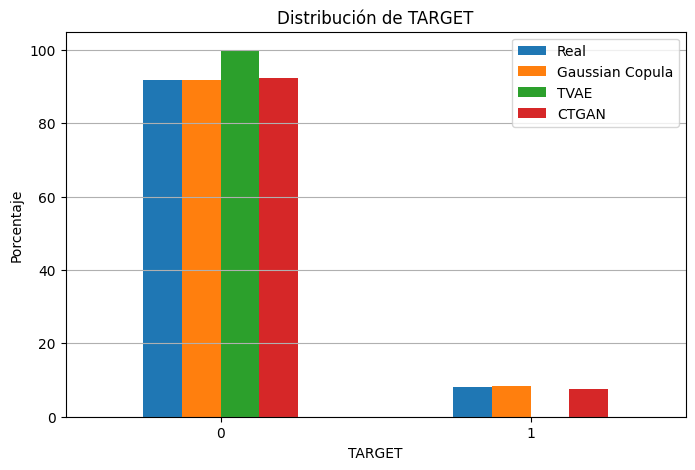

In [ ]:
#Grafica
import matplotlib.pyplot as plt

comparacion = pd.DataFrame({

    "Real": df_real["TARGET"].value_counts(normalize=True).sort_index()*100,
    "Gaussian Copula": gc_sample["TARGET"].value_counts(normalize=True).sort_index()*100,
    "TVAE": df_tvae_sample["TARGET"].value_counts(normalize=True).sort_index()*100,
    "CTGAN": df_ctgan_sample["TARGET"].value_counts(normalize=True).sort_index()*100

})

comparacion.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Porcentaje")
plt.title("Distribución de TARGET")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

#### 3.5.2 Evaluación estadística

In [ ]:
#IDentificacion de las variables numericas
import numpy as np

numeric_columns = df_experiment.select_dtypes(include=np.number).columns.tolist()

# Excluir TARGET del análisis estadístico
numeric_columns.remove("TARGET")

print(f"Número de variables numéricas: {len(numeric_columns)}")

numeric_columns

Número de variables numéricas: 28


['SK_ID_CURR',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'AMT_REQ_CREDIT_BUREAU_YEAR',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'DAYS_BIRTH',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'DAYS_EMPLOYED',
 'OWN_CAR_AGE',
 'HOUR_APPR_PROCESS_START',
 'AGE',
 'EMPLOYMENT_YEARS',
 'HAS_CAR_AGE',
 'CREDIT_INCOME_RATIO',
 'ANNUITY_INCOME_RATIO',
 'CREDIT_GOODS_RATIO',
 'INCOME_PER_FAMILY',
 'CHILDREN_RATIO',
 'CREDIT_TERM_EST']

In [ ]:
#Función para evaluar un sintetizador
from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance

import numpy as np
import pandas as pd

In [ ]:
def evaluar_sintetizador(df_real,
                         df_sintetico,
                         columnas):

    resultados = []

    for col in columnas:

        real = df_real[col].dropna()

        sint = df_sintetico[col].dropna()

        # KS Test
        ks = ks_2samp(real, sint).statistic

        # Wasserstein
        wass = wasserstein_distance(real, sint)

        resultados.append({

            "Variable": col,

            "KS": ks,

            "Wasserstein": wass,

            "Media_real": real.mean(),

            "Media_sint": sint.mean(),

            "STD_real": real.std(),

            "STD_sint": sint.std()

        })

    return pd.DataFrame(resultados)

In [ ]:
#Evaluación de Gaussian Copula, TVAE y CTGAN.
gc_metrics = evaluar_sintetizador(

    df_experiment,

    gc_sample,

    numeric_columns

)

gc_metrics.head()

,Variable,KS,Wasserstein,Media_real,Media_sint,STD_real,STD_sint
0,SK_ID_CURR,0.97100,8.094567e+06,278344.994200,8.372369e+06,102517.015850,4.908756e+06
1,AMT_INCOME_TOTAL,0.06410,8.037111e+03,168013.445951,1.661009e+05,97666.503609,8.261318e+04
2,AMT_CREDIT,0.05500,1.680331e+04,597415.017375,5.958943e+05,401174.022988,3.962572e+05
3,AMT_ANNUITY,0.02120,4.057215e+02,27032.171850,2.694836e+04,14515.575553,1.401478e+04
4,AMT_GOODS_PRICE,0.07795,2.636238e+04,537216.478425,5.359519e+05,368096.414865,3.636127e+05


In [ ]:
#TVAE
tvae_metrics = evaluar_sintetizador(

    df_experiment,

    df_tvae_sample,

    numeric_columns

)

In [ ]:
#CTGAN
ctgan_metrics = evaluar_sintetizador(

    df_experiment,

    df_ctgan_sample,

    numeric_columns

)

In [ ]:
#Tabla resumen
resumen = pd.DataFrame({

    "Modelo":[

        "Gaussian Copula",

        "TVAE",

        "CTGAN"

    ],

    "KS promedio":[

        gc_metrics["KS"].mean(),

        tvae_metrics["KS"].mean(),

        ctgan_metrics["KS"].mean()

    ],

    "Wasserstein promedio":[

        gc_metrics["Wasserstein"].mean(),

        tvae_metrics["Wasserstein"].mean(),

        ctgan_metrics["Wasserstein"].mean()

    ]

})

resumen.round(4)

,Modelo,KS promedio,Wasserstein promedio
0,Gaussian Copula,0.1806,291168.7084
1,TVAE,0.2020,293139.6224
2,CTGAN,0.1546,292290.6571


In [ ]:
#Ranking
#Normalizaremos las métricas para poder construir un índice global de calidad.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

metricas = resumen.copy()

metricas[["KS promedio",
          "Wasserstein promedio"]] = scaler.fit_transform(

metricas[["KS promedio",
          "Wasserstein promedio"]]

)

In [ ]:
#Valores mas pequeños indican mejor calidad, invirtamos la escala
metricas["Score"] = (

1-metricas["KS promedio"] +

1-metricas["Wasserstein promedio"]

)/2

metricas.sort_values(

"Score",

ascending=False

)

,Modelo,KS promedio,Wasserstein promedio,Score
0,Gaussian Copula,0.548662,0.000000,7.256692e-01
2,CTGAN,0.000000,0.569253,7.153735e-01
1,TVAE,1.000000,1.000000,-2.220446e-16


#### 3.5.3 Conservación de estadísticas descriptivas

**5.5.2 Conservación de estadísticas descriptivas**

Con el objetivo de evaluar la fidelidad de los datos sintéticos generados, se compararon las principales estadísticas descriptivas de todas las variables numéricas entre el conjunto de datos real y cada uno de los conjuntos sintéticos.

Para cada variable se calcularon la media y la desviación estándar, así como el error relativo porcentual respecto al conjunto original.

Una menor diferencia indica una mejor capacidad del sintetizador para preservar las propiedades estadísticas fundamentales del dominio de riesgo crediticio.

In [ ]:
#Funcion de evaluacion
import numpy as np
import pandas as pd

def error_estadistico(metricas):

    resultados = metricas.copy()

    # Error de la media
    resultados["Error Media (%)"] = np.where(
        resultados["Media_real"] != 0,
        np.abs(resultados["Media_real"] - resultados["Media_sint"]) /
        np.abs(resultados["Media_real"]) * 100,
        0
    )

    # Error de la desviación estándar
    resultados["Error STD (%)"] = np.where(
        resultados["STD_real"] != 0,
        np.abs(resultados["STD_real"] - resultados["STD_sint"]) /
        np.abs(resultados["STD_real"]) * 100,
        0
    )

    return resultados

In [ ]:
#Aplicar la funcion
gc_metrics = error_estadistico(gc_metrics)
tvae_metrics = error_estadistico(tvae_metrics)
ctgan_metrics = error_estadistico(ctgan_metrics)

In [ ]:
#Visualizar algunas variables
gc_metrics[
    [
        "Variable",
        "Media_real",
        "Media_sint",
        "Error Media (%)",
        "STD_real",
        "STD_sint",
        "Error STD (%)"
    ]
].head(10)

,Variable,Media_real,Media_sint,Error Media (%),STD_real,STD_sint,Error STD (%)
0,SK_ID_CURR,278344.994200,8.372369e+06,2907.910880,102517.015850,4.908756e+06,4688.235074
1,AMT_INCOME_TOTAL,168013.445951,1.661009e+05,1.138343,97666.503609,8.261318e+04,15.412987
2,AMT_CREDIT,597415.017375,5.958943e+05,0.254542,401174.022988,3.962572e+05,1.225599
3,AMT_ANNUITY,27032.171850,2.694836e+04,0.310052,14515.575553,1.401478e+04,3.450054
4,AMT_GOODS_PRICE,537216.478425,5.359519e+05,0.235403,368096.414865,3.636127e+05,1.218088
5,AMT_REQ_CREDIT_BUREAU_YEAR,1.771250,1.448200e+00,18.238532,1.753818,2.365594e+00,34.882544
6,OBS_30_CNT_SOCIAL_CIRCLE,1.423000,2.502400e+00,75.853830,2.334833,1.713646e+00,26.605203
7,DEF_30_CNT_SOCIAL_CIRCLE,0.145100,1.504000e-01,3.652653,0.453383,4.598066e-01,1.416789
8,OBS_60_CNT_SOCIAL_CIRCLE,1.405350,3.194000e-01,77.272566,2.313311,9.975884e-01,56.876169
9,DEF_60_CNT_SOCIAL_CIRCLE,0.097650,9.600000e-02,1.689708,0.356119,3.452649e-01,3.047919


In [ ]:
#Resumane comparativo
estadisticas = pd.DataFrame({

    "Modelo":[
        "Gaussian Copula",
        "TVAE",
        "CTGAN"
    ],

    "Error Medio (%)":[

        gc_metrics["Error Media (%)"].mean(),

        tvae_metrics["Error Media (%)"].mean(),

        ctgan_metrics["Error Media (%)"].mean()

    ],

    "Error STD (%)":[

        gc_metrics["Error STD (%)"].mean(),

        tvae_metrics["Error STD (%)"].mean(),

        ctgan_metrics["Error STD (%)"].mean()

    ]

})

estadisticas.round(2)

,Modelo,Error Medio (%),Error STD (%)
0,Gaussian Copula,117.43,182.39
1,TVAE,121.55,202.22
2,CTGAN,120.72,180.13


In [ ]:
#Ranking por estadísticas descriptivas
estadisticas = estadisticas.sort_values(
    by=["Error Medio (%)", "Error STD (%)"],
    ascending=True
)

estadisticas.reset_index(drop=True)

,Modelo,Error Medio (%),Error STD (%)
0,Gaussian Copula,117.430844,182.391059
1,CTGAN,120.719727,180.131736
2,TVAE,121.552870,202.219219


#### 3.5.4 Conservación de la estructura de correlaciones

**5.5.3 Conservación de la estructura de correlaciones**

Además de preservar las distribuciones individuales de las variables, un conjunto de datos sintético debe mantener las relaciones existentes entre ellas.

Para evaluar este aspecto, se calcularon las matrices de correlación de Pearson para el conjunto de datos real y para cada conjunto sintético.

Posteriormente se compararon ambas matrices mediante el Error Absoluto Medio (MAE) entre los coeficientes de correlación, permitiendo cuantificar el grado de conservación de la estructura de dependencia entre variables.

In [ ]:
#Matriz de correlación del dataset real
corr_real = df_experiment[numeric_columns].corr(method="pearson")

In [ ]:
#Matrices de los sintetizadores
corr_gc = gc_sample[numeric_columns].corr(method="pearson")

corr_tvae = df_tvae_sample[numeric_columns].corr(method="pearson")

corr_ctgan = df_ctgan_sample[numeric_columns].corr(method="pearson")

In [ ]:
#Función para evaluar correlaciones
import numpy as np

def evaluar_correlacion(corr_real, corr_sint):

    diferencia = np.abs(corr_real - corr_sint)

    np.fill_diagonal(diferencia.values, np.nan)

    mae = np.nanmean(diferencia.values)

    return mae

In [ ]:
#Calcular el MAE
mae_gc = evaluar_correlacion(corr_real, corr_gc)

mae_tvae = evaluar_correlacion(corr_real, corr_tvae)

mae_ctgan = evaluar_correlacion(corr_real, corr_ctgan)

In [ ]:
#Resumen
correlaciones = pd.DataFrame({

    "Modelo":[
        "Gaussian Copula",
        "TVAE",
        "CTGAN"
    ],

    "Correlation MAE":[
        mae_gc,
        mae_tvae,
        mae_ctgan
    ]

})

correlaciones.sort_values(
    by="Correlation MAE",
    ascending=True
).round(4)

,Modelo,Correlation MAE
0,Gaussian Copula,0.0293
2,CTGAN,0.0526
1,TVAE,0.0799


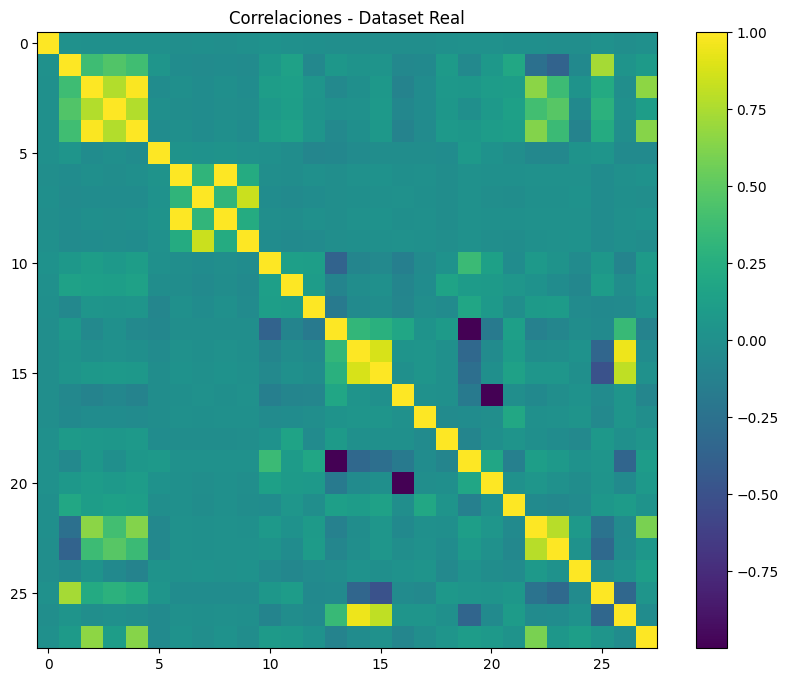

In [ ]:
#Visualizacion de matricez
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(corr_real, aspect="auto")

plt.title("Correlaciones - Dataset Real")

plt.colorbar()

plt.show()

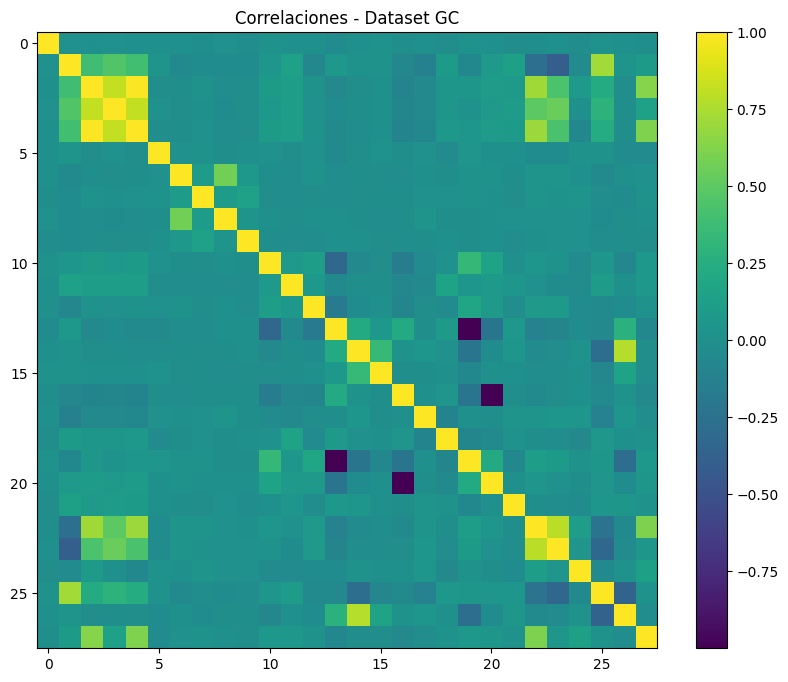

In [ ]:
plt.figure(figsize=(10,8))

plt.imshow(corr_gc, aspect="auto")

plt.title("Correlaciones - Dataset GC")

plt.colorbar()

plt.show()

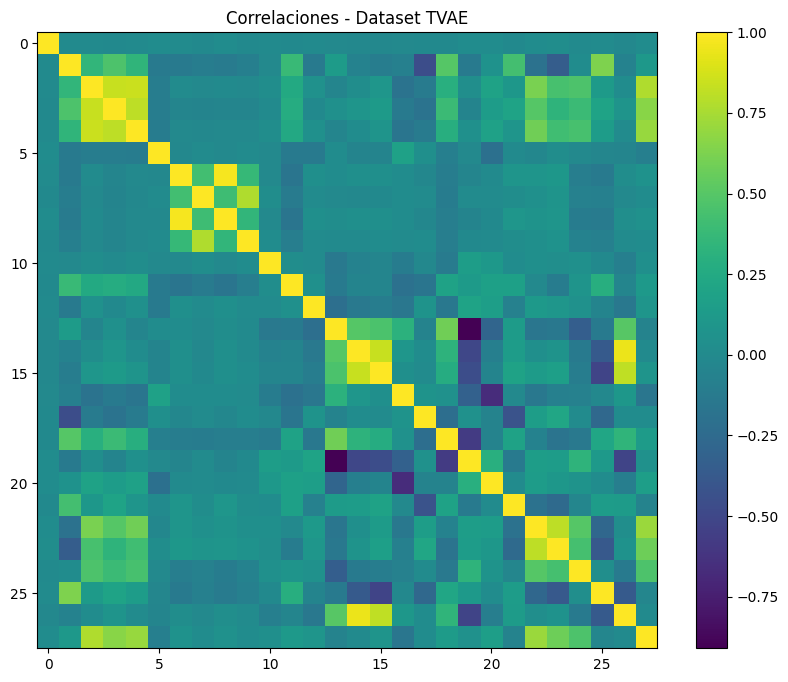

In [ ]:
plt.figure(figsize=(10,8))

plt.imshow(corr_tvae, aspect="auto")

plt.title("Correlaciones - Dataset TVAE")

plt.colorbar()

plt.show()

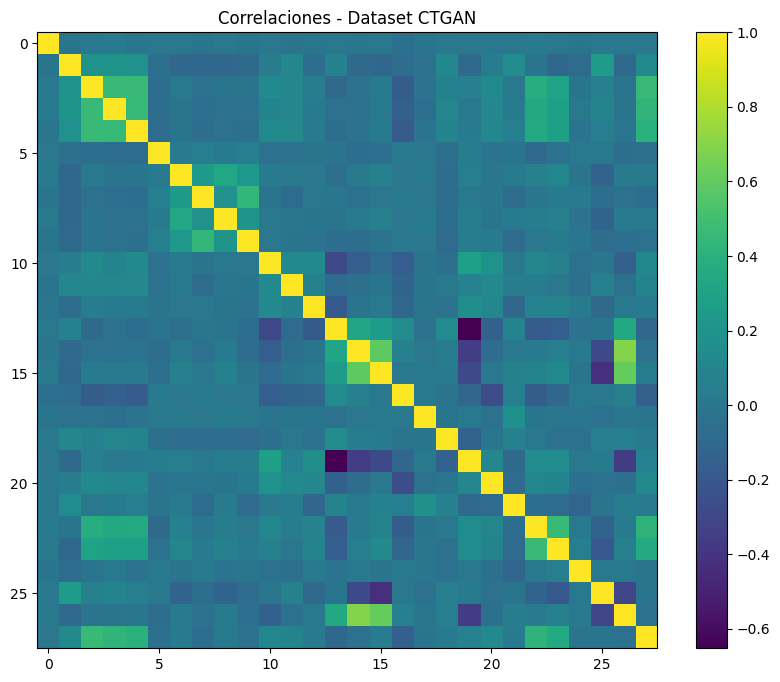

In [ ]:
plt.figure(figsize=(10,8))

plt.imshow(corr_ctgan, aspect="auto")

plt.title("Correlaciones - Dataset CTGAN")

plt.colorbar()

plt.show()

In [ ]:
#MAtriz de diferencia de corelacion
abs(corr_real - corr_gc)

,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_REQ_CREDIT_BUREAU_YEAR,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,CNT_CHILDREN,CNT_FAM_MEMBERS,DAYS_EMPLOYED,OWN_CAR_AGE,HOUR_APPR_PROCESS_START,AGE,EMPLOYMENT_YEARS,HAS_CAR_AGE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_FAMILY,CHILDREN_RATIO,CREDIT_TERM_EST
SK_ID_CURR,0.000000,0.002451,0.001714,0.005388,0.000867,0.006880,0.014736,0.002733,0.024397,0.027496,0.003004,0.002433,0.003873,0.017910,0.020409,0.031553,0.007991,0.013769,0.013309,0.017820,0.007968,0.007256,0.000267,0.013459,0.004860,0.003532,0.013415,0.005295
AMT_INCOME_TOTAL,0.002451,0.000000,0.014078,0.002472,0.010236,0.008058,0.014470,0.011041,0.001741,0.012888,0.013640,0.000516,0.011318,0.004946,0.004836,0.008818,0.009216,0.067559,0.001788,0.005206,0.010099,0.062035,0.013262,0.032387,0.015463,0.011192,0.002258,0.001152
AMT_CREDIT,0.001714,0.014078,0.000000,0.048740,0.000091,0.016052,0.001647,0.044647,0.016941,0.013901,0.022375,0.013497,0.015362,0.002938,0.011937,0.064199,0.006031,0.027856,0.008920,0.002987,0.005797,0.034120,0.069804,0.062176,0.045769,0.009106,0.000526,0.022173
AMT_ANNUITY,0.005388,0.002472,0.048740,0.000000,0.042728,0.013814,0.001949,0.030861,0.009829,0.008544,0.004317,0.007453,0.020352,0.030120,0.019169,0.068282,0.008061,0.029327,0.001982,0.029893,0.008410,0.042408,0.106252,0.062947,0.051155,0.008567,0.008055,0.026426
AMT_GOODS_PRICE,0.000867,0.010236,0.000091,0.042728,0.000000,0.017144,0.000326,0.042805,0.016008,0.012707,0.023451,0.020339,0.016667,0.006122,0.011838,0.064742,0.009249,0.029786,0.009955,0.006162,0.009075,0.032788,0.071566,0.061986,0.040938,0.010129,0.000309,0.019509
AMT_REQ_CREDIT_BUREAU_YEAR,0.006880,0.008058,0.016052,0.013814,0.017144,0.000000,0.013172,0.002557,0.028207,0.011716,0.008809,0.007513,0.091053,0.026315,0.026533,0.050541,0.012489,0.029578,0.007538,0.026389,0.012335,0.015634,0.037585,0.040843,0.003479,0.013052,0.019084,0.009182
OBS_30_CNT_SOCIAL_CIRCLE,0.014736,0.014470,0.001647,0.001949,0.000326,0.013172,0.000000,0.206535,0.425583,0.158074,0.007502,0.004010,0.022239,0.008225,0.013854,0.032524,0.016694,0.006401,0.017901,0.008242,0.016604,0.005388,0.017660,0.022922,0.009105,0.021652,0.001844,0.006152
DEF_30_CNT_SOCIAL_CIRCLE,0.002733,0.011041,0.044647,0.030861,0.042805,0.002557,0.206535,0.000000,0.212689,0.700433,0.016787,0.018216,0.015777,0.001341,0.008107,0.008882,0.014932,0.018178,0.025603,0.001358,0.015109,0.001536,0.032798,0.019354,0.013041,0.011395,0.020414,0.039871
OBS_60_CNT_SOCIAL_CIRCLE,0.024397,0.001741,0.016941,0.009829,0.016008,0.028207,0.425583,0.212689,0.000000,0.191754,0.014777,0.011479,0.003159,0.013287,0.012769,0.034396,0.002340,0.031863,0.015767,0.013278,0.002201,0.014992,0.003548,0.000874,0.003028,0.000543,0.007566,0.009402
DEF_60_CNT_SOCIAL_CIRCLE,0.027496,0.012888,0.013901,0.008544,0.012707,0.011716,0.158074,0.700433,0.191754,0.000000,0.018472,0.026741,0.015209,0.013317,0.003379,0.018040,0.013519,0.002084,0.022502,0.013359,0.013664,0.004902,0.004076,0.000595,0.001251,0.011141,0.003031,0.007682


In [ ]:
abs(corr_real - corr_tvae)

,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_REQ_CREDIT_BUREAU_YEAR,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,CNT_CHILDREN,CNT_FAM_MEMBERS,DAYS_EMPLOYED,OWN_CAR_AGE,HOUR_APPR_PROCESS_START,AGE,EMPLOYMENT_YEARS,HAS_CAR_AGE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_FAMILY,CHILDREN_RATIO,CREDIT_TERM_EST
SK_ID_CURR,0.000000,0.004840,0.005662,0.007024,0.002818,0.009120,0.025096,0.000412,0.025403,0.011124,0.010104,0.004701,0.005022,0.002961,0.005986,0.009307,0.003654,0.001974,0.007212,0.006363,0.004205,0.004979,0.021149,0.034491,0.019312,0.000062,0.004971,0.019471
AMT_INCOME_TOTAL,0.004840,0.000000,0.030071,0.009061,0.040882,0.174995,0.094318,0.063043,0.087999,0.044734,0.075446,0.242073,0.056114,0.074267,0.088458,0.131131,0.014399,0.405822,0.412142,0.068624,0.002458,0.225708,0.068988,0.022734,0.070831,0.104073,0.091672,0.021189
AMT_CREDIT,0.005662,0.030071,0.000000,0.072061,0.143071,0.075245,0.012214,0.011865,0.007318,0.014145,0.085127,0.115634,0.015395,0.019409,0.028688,0.023990,0.082107,0.086677,0.224696,0.024591,0.090068,0.013362,0.032722,0.075631,0.440783,0.090477,0.032925,0.110606
AMT_ANNUITY,0.007024,0.009061,0.072061,0.000000,0.037900,0.095534,0.026608,0.021849,0.028933,0.016946,0.070501,0.148739,0.036561,0.043659,0.068589,0.054458,0.057902,0.155665,0.329766,0.042363,0.073493,0.054338,0.104199,0.149139,0.438922,0.083501,0.074889,0.549366
AMT_GOODS_PRICE,0.002818,0.040882,0.143071,0.037900,0.000000,0.075777,0.005315,0.011796,0.006469,0.018895,0.091203,0.102331,0.004672,0.015133,0.023268,0.014459,0.063734,0.078789,0.211482,0.010882,0.078977,0.032820,0.044829,0.056033,0.554054,0.083285,0.028436,0.070124
AMT_REQ_CREDIT_BUREAU_YEAR,0.009120,0.174995,0.075245,0.095534,0.075777,0.000000,0.043014,0.012729,0.041397,0.004674,0.018125,0.108239,0.053966,0.090280,0.013433,0.027599,0.203341,0.064630,0.056523,0.084265,0.221635,0.014579,0.044378,0.087524,0.039560,0.070726,0.000792,0.039190
OBS_30_CNT_SOCIAL_CIRCLE,0.025096,0.094318,0.012214,0.026608,0.005315,0.043014,0.000000,0.113692,0.023885,0.138334,0.001318,0.145070,0.038167,0.029112,0.029858,0.022761,0.018626,0.024391,0.080092,0.046797,0.000467,0.086512,0.071587,0.094270,0.109558,0.093436,0.024101,0.043971
DEF_30_CNT_SOCIAL_CIRCLE,0.000412,0.063043,0.011865,0.021849,0.011796,0.012729,0.113692,0.000000,0.090893,0.065315,0.049133,0.072154,0.043230,0.003903,0.017929,0.009115,0.009969,0.017253,0.087721,0.005969,0.020486,0.045181,0.048559,0.071671,0.087475,0.051096,0.005163,0.031380
OBS_60_CNT_SOCIAL_CIRCLE,0.025403,0.087999,0.007318,0.028933,0.006469,0.041397,0.023885,0.090893,0.000000,0.117552,0.000229,0.148780,0.036050,0.038225,0.033773,0.022580,0.021914,0.028405,0.071413,0.055451,0.005595,0.091509,0.057201,0.075210,0.123354,0.085414,0.027001,0.036327
DEF_60_CNT_SOCIAL_CIRCLE,0.011124,0.044734,0.014145,0.016946,0.018895,0.004674,0.138334,0.065315,0.117552,0.000000,0.043040,0.051046,0.044272,0.019124,0.005093,0.013648,0.002040,0.022308,0.077336,0.016982,0.018221,0.041834,0.040630,0.057582,0.079926,0.047224,0.015537,0.031218


In [ ]:
abs(corr_real - corr_ctgan)

,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_REQ_CREDIT_BUREAU_YEAR,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,CNT_CHILDREN,CNT_FAM_MEMBERS,DAYS_EMPLOYED,OWN_CAR_AGE,HOUR_APPR_PROCESS_START,AGE,EMPLOYMENT_YEARS,HAS_CAR_AGE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_FAMILY,CHILDREN_RATIO,CREDIT_TERM_EST
SK_ID_CURR,0.000000,0.019873,0.005550,0.022932,0.014146,0.007988,0.021365,0.007428,0.020724,0.018059,0.016342,0.017822,0.000670,0.019399,0.011553,0.016836,0.037863,0.000921,0.015908,0.007820,0.003752,0.008335,0.022517,0.015545,0.000645,0.005524,0.017724,0.000927
AMT_INCOME_TOTAL,0.019873,0.000000,0.181273,0.254142,0.202048,0.088816,0.074735,0.054647,0.074866,0.043351,0.019077,0.031380,0.007278,0.012092,0.105265,0.125707,0.000128,0.019698,0.035422,0.019524,0.020528,0.056389,0.248545,0.274325,0.011596,0.470844,0.109923,0.042846
AMT_CREDIT,0.005550,0.181273,0.000000,0.301710,0.517620,0.029982,0.015367,0.010087,0.014108,0.006085,0.018877,0.022142,0.001564,0.023656,0.028687,0.046079,0.066201,0.005433,0.007538,0.009842,0.027134,0.104951,0.273847,0.063821,0.035418,0.159273,0.005409,0.201995
AMT_ANNUITY,0.022932,0.254142,0.301710,0.000000,0.319079,0.050543,0.002371,0.021542,0.013990,0.014106,0.019467,0.003578,0.002248,0.034357,0.042901,0.057157,0.073730,0.015756,0.037659,0.021735,0.040171,0.120660,0.041415,0.193246,0.062240,0.191633,0.024456,0.312472
AMT_GOODS_PRICE,0.014146,0.202048,0.517620,0.319079,0.000000,0.037270,0.005309,0.024830,0.024273,0.020422,0.021030,0.014857,0.014405,0.000218,0.020029,0.027622,0.076210,0.012909,0.015686,0.023330,0.013738,0.068797,0.271859,0.075392,0.083052,0.171214,0.011593,0.233698
AMT_REQ_CREDIT_BUREAU_YEAR,0.007988,0.088816,0.029982,0.050543,0.037270,0.000000,0.003442,0.037346,0.001105,0.047942,0.036226,0.002497,0.059913,0.052782,0.018722,0.025637,0.038799,0.031082,0.010484,0.033045,0.043010,0.002958,0.011346,0.027007,0.015084,0.022932,0.012269,0.003372
OBS_30_CNT_SOCIAL_CIRCLE,0.021365,0.074735,0.015367,0.002371,0.005309,0.003442,0.000000,0.074444,0.657343,0.000190,0.043588,0.039950,0.000629,0.030158,0.006095,0.047423,0.005265,0.016651,0.043352,0.046355,0.003844,0.023922,0.052275,0.094648,0.031845,0.098865,0.017984,0.011890
DEF_30_CNT_SOCIAL_CIRCLE,0.007428,0.054647,0.010087,0.021542,0.024830,0.037346,0.074444,0.000000,0.132133,0.399514,0.008059,0.025647,0.032408,0.008167,0.029313,0.001301,0.004613,0.008185,0.042263,0.002360,0.005040,0.050681,0.007115,0.020843,0.010535,0.023967,0.020364,0.045971
OBS_60_CNT_SOCIAL_CIRCLE,0.020724,0.074866,0.014108,0.013990,0.024273,0.001105,0.657343,0.132133,0.000000,0.024988,0.017630,0.019523,0.016881,0.009728,0.013328,0.046446,0.008522,0.032980,0.036366,0.030911,0.010981,0.026143,0.026308,0.056801,0.036625,0.093015,0.033503,0.002106
DEF_60_CNT_SOCIAL_CIRCLE,0.018059,0.043351,0.006085,0.014106,0.020422,0.047942,0.000190,0.399514,0.024988,0.000000,0.024622,0.030346,0.012568,0.040814,0.060194,0.020547,0.010156,0.007295,0.062082,0.030192,0.033822,0.055651,0.001447,0.014639,0.020939,0.033824,0.042719,0.011956


#### 3.5.5 Conservación de distribuciones (KS y Wasserstein)



Objetivo

Evaluar la similitud entre las distribuciones de las variables del conjunto de datos real y las generadas sintéticamente mediante dos métricas ampliamente utilizadas en la literatura:

Kolmogorov–Smirnov (KS): mide la diferencia máxima entre dos funciones de distribución acumulada.
Wasserstein Distance (Earth Mover's Distance): mide el esfuerzo necesario para transformar una distribución en otra.

Mientras más pequeños sean ambos valores, mayor será la similitud entre las distribuciones.

In [ ]:
#importacion de las metricas
from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance

In [ ]:
#Seleccionamos unicamente las variables numericas:
numeric_cols = df_experiment.select_dtypes(
    include=["number"]
).columns.tolist()

numeric_cols

['TARGET',
 'SK_ID_CURR',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'AMT_REQ_CREDIT_BUREAU_YEAR',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'DAYS_BIRTH',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'DAYS_EMPLOYED',
 'OWN_CAR_AGE',
 'HOUR_APPR_PROCESS_START',
 'AGE',
 'EMPLOYMENT_YEARS',
 'HAS_CAR_AGE',
 'CREDIT_INCOME_RATIO',
 'ANNUITY_INCOME_RATIO',
 'CREDIT_GOODS_RATIO',
 'INCOME_PER_FAMILY',
 'CHILDREN_RATIO',
 'CREDIT_TERM_EST']

In [ ]:
#Creamos una funcion para evaluar un sintetizador
def evaluar_distribuciones(df_real, df_sintetico):

    resultados = []

    for col in numeric_cols:

        real = df_real[col].dropna()
        sint = df_sintetico[col].dropna()

        ks, _ = ks_2samp(real, sint)

        wasserstein = wasserstein_distance(
            real,
            sint
        )

        resultados.append({

            "Variable": col,
            "KS": ks,
            "Wasserstein": wasserstein

        })

    return pd.DataFrame(resultados)

In [ ]:
#GC
gc_dist = evaluar_distribuciones(
    df_experiment,
    gc_sample
)

gc_dist.head()

,Variable,KS,Wasserstein
0,TARGET,0.00225,2.250000e-03
1,SK_ID_CURR,0.97100,8.094567e+06
2,AMT_INCOME_TOTAL,0.06410,8.037111e+03
3,AMT_CREDIT,0.05500,1.680331e+04
4,AMT_ANNUITY,0.02120,4.057215e+02


In [ ]:
#TVAE
tvae_dist = evaluar_distribuciones(
    df_experiment,
    df_tvae_sample
)

tvae_dist.head()

,Variable,KS,Wasserstein
0,TARGET,0.08075,8.075000e-02
1,SK_ID_CURR,0.97100,8.094567e+06
2,AMT_INCOME_TOTAL,0.12160,1.929739e+04
3,AMT_CREDIT,0.04870,3.434437e+04
4,AMT_ANNUITY,0.08810,3.051954e+03


In [ ]:
#CTGAN
ctgan_dist = evaluar_distribuciones(
    df_experiment,
    df_ctgan_sample
)

ctgan_dist.head()

,Variable,KS,Wasserstein
0,TARGET,0.00475,4.750000e-03
1,SK_ID_CURR,0.97100,8.094567e+06
2,AMT_INCOME_TOTAL,0.09785,7.328823e+03
3,AMT_CREDIT,0.08630,3.894698e+04
4,AMT_ANNUITY,0.05135,1.326553e+03


In [ ]:
#Resumen global
ranking_dist = pd.DataFrame({

    "Modelo":[
        "Gaussian Copula",
        "TVAE",
        "CTGAN"
    ],

    "KS Medio":[

        gc_dist["KS"].mean(),
        tvae_dist["KS"].mean(),
        ctgan_dist["KS"].mean()

    ],

    "Wasserstein Medio":[

        gc_dist["Wasserstein"].mean(),
        tvae_dist["Wasserstein"].mean(),
        ctgan_dist["Wasserstein"].mean()

    ]

})

ranking_dist

,Modelo,KS Medio,Wasserstein Medio
0,Gaussian Copula,0.174426,281128.408162
1,TVAE,0.197802,283031.362316
2,CTGAN,0.149386,282211.669103


In [ ]:
#Ordenemos por ambas métricas para visualizar rápidamente el mejor modelo.
ranking_dist = ranking_dist.sort_values(
    by=["KS Medio", "Wasserstein Medio"]
)

ranking_dist

,Modelo,KS Medio,Wasserstein Medio
2,CTGAN,0.149386,282211.669103
0,Gaussian Copula,0.174426,281128.408162
1,TVAE,0.197802,283031.362316


#### 3.5.6 Comparación visual de distribuciones

Objetivo

Comparar visualmente la distribución de las principales variables numéricas entre:

Dataset real
Gaussian Copula
TVAE
CTGAN

Se utilizarán histogramas con curvas de densidad (KDE), permitiendo evaluar de manera cualitativa la capacidad de cada sintetizador para reproducir la forma de las distribuciones originales.

In [ ]:
#Eleccion de variables
variables_plot = [

    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AGE",
    "EXT_SOURCE_2",
    "CREDIT_TERM_EST"

]

In [ ]:
#Importamos librerias
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
#Funcion reutilizable
def comparar_distribucion(variable):

    fig, axes = plt.subplots(2, 2, figsize=(14,8))

    datasets = [
        ("Gaussian Copula", gc_sample),
        ("TVAE", df_tvae_sample),
        ("CTGAN", df_ctgan_sample)
    ]

    posiciones = [(0,1),(1,0),(1,1)]

    # Dataset real

    sns.histplot(
        df_experiment[variable],
        bins=40,
        stat="density",
        kde=True,
        ax=axes[0,0]
    )

    axes[0,0].set_title("Real")

    # Sintéticos

    for (nombre, df_syn), pos in zip(datasets, posiciones):

        sns.histplot(
            df_syn[variable],
            bins=40,
            stat="density",
            kde=True,
            ax=axes[pos]
        )

        axes[pos].set_title(nombre)

    plt.suptitle(variable, fontsize=15)

    plt.tight_layout()

    plt.show()

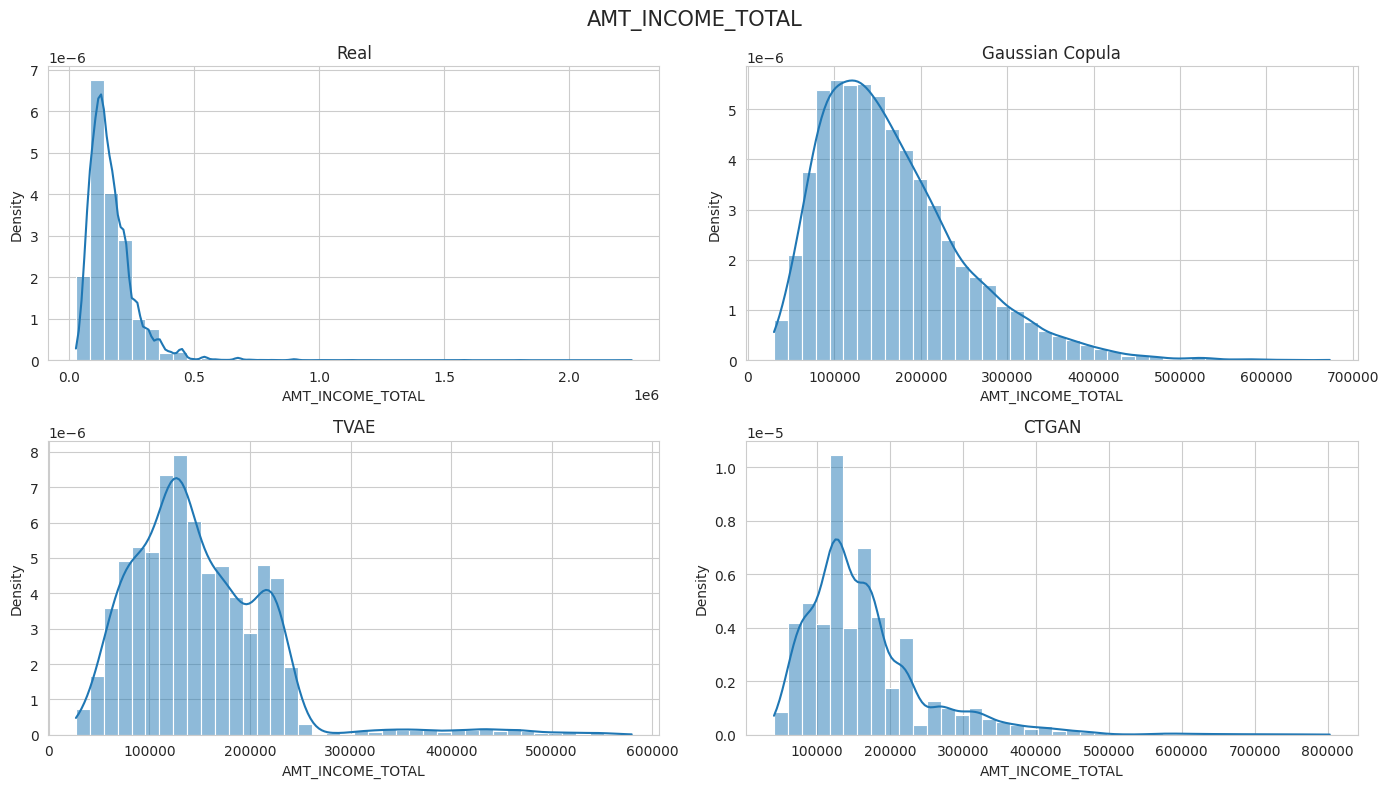

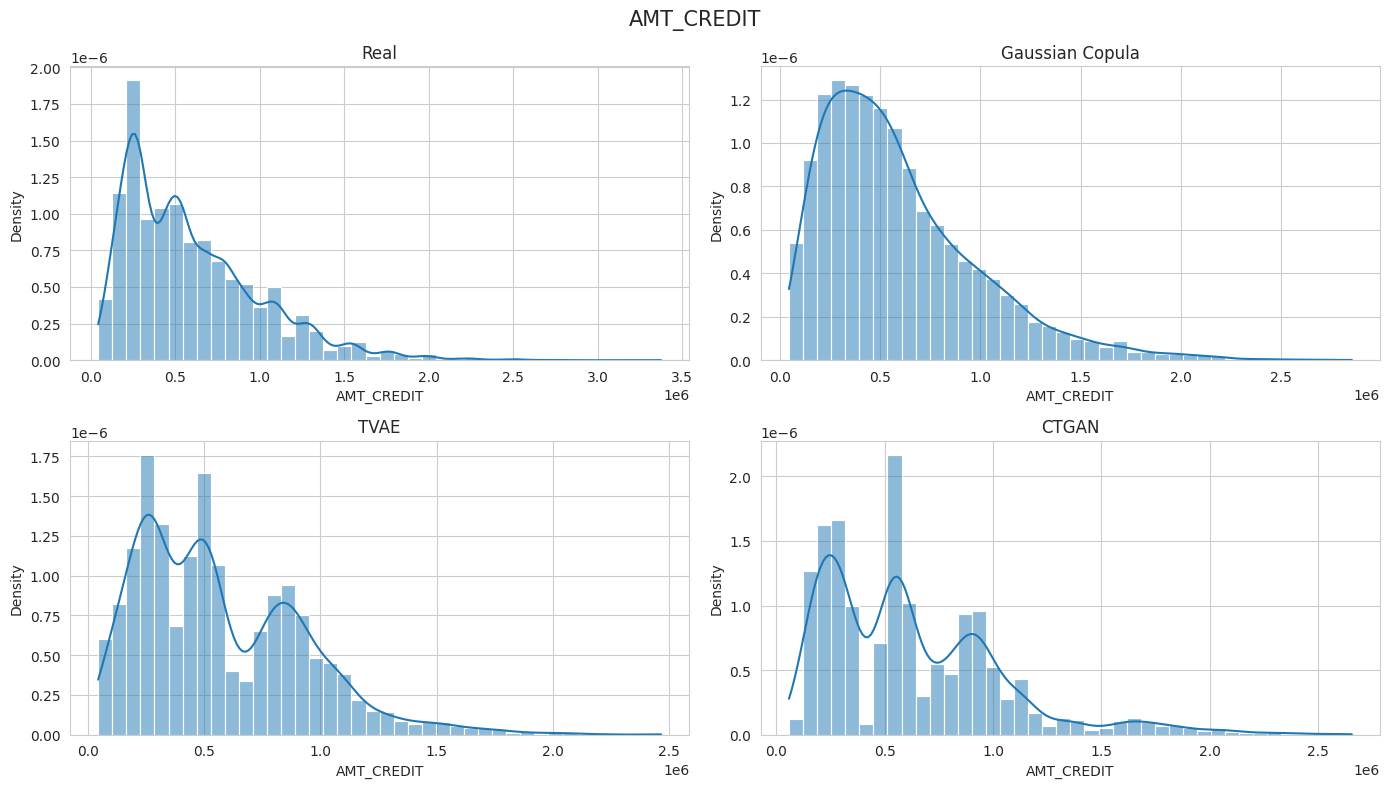

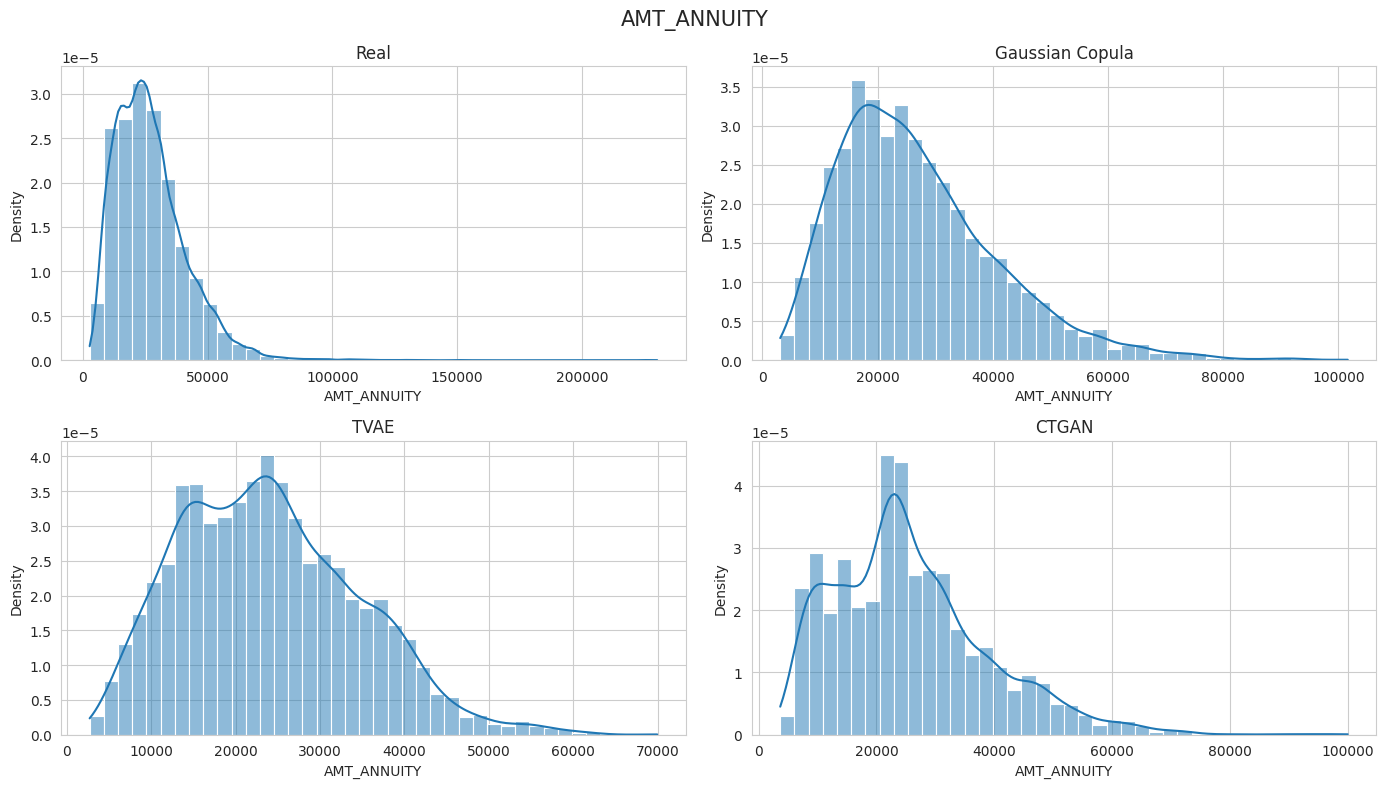

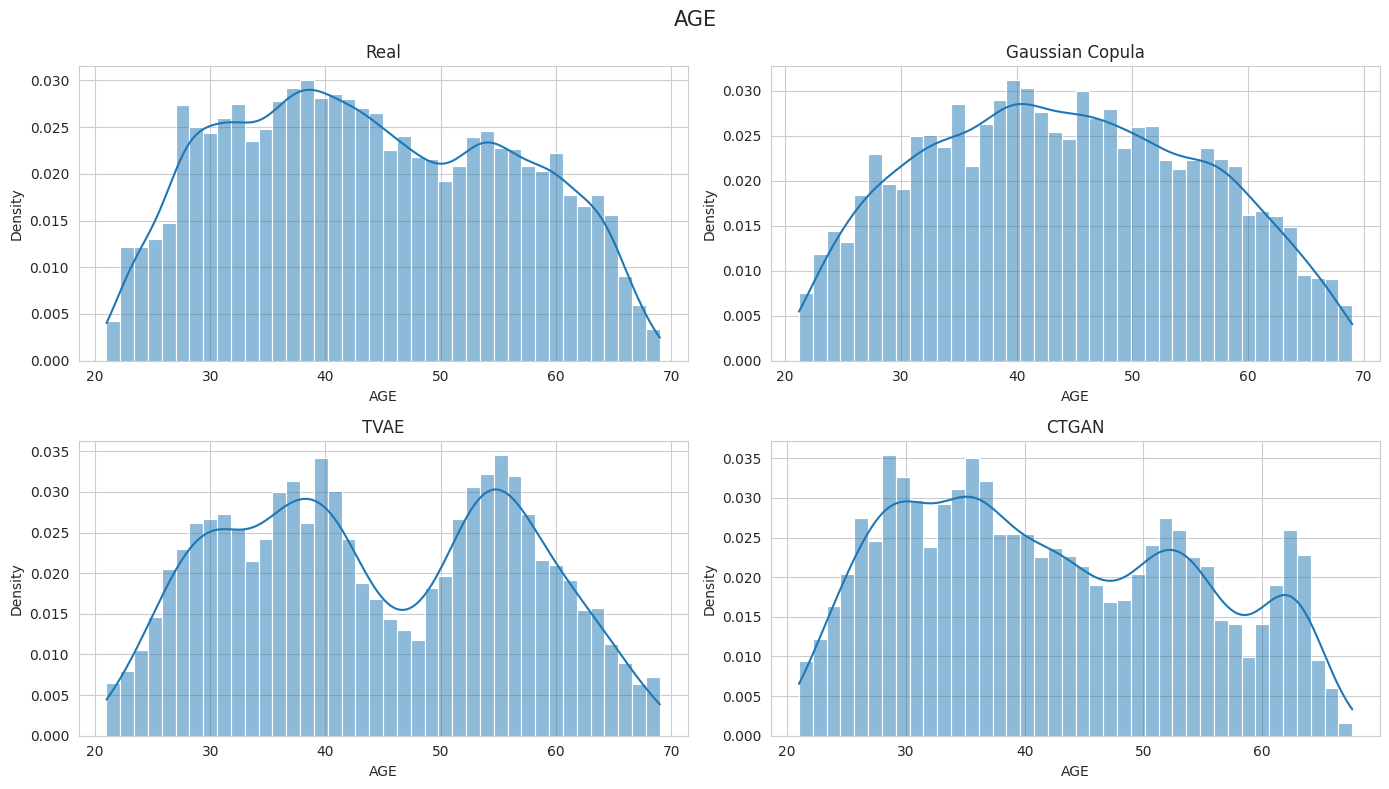

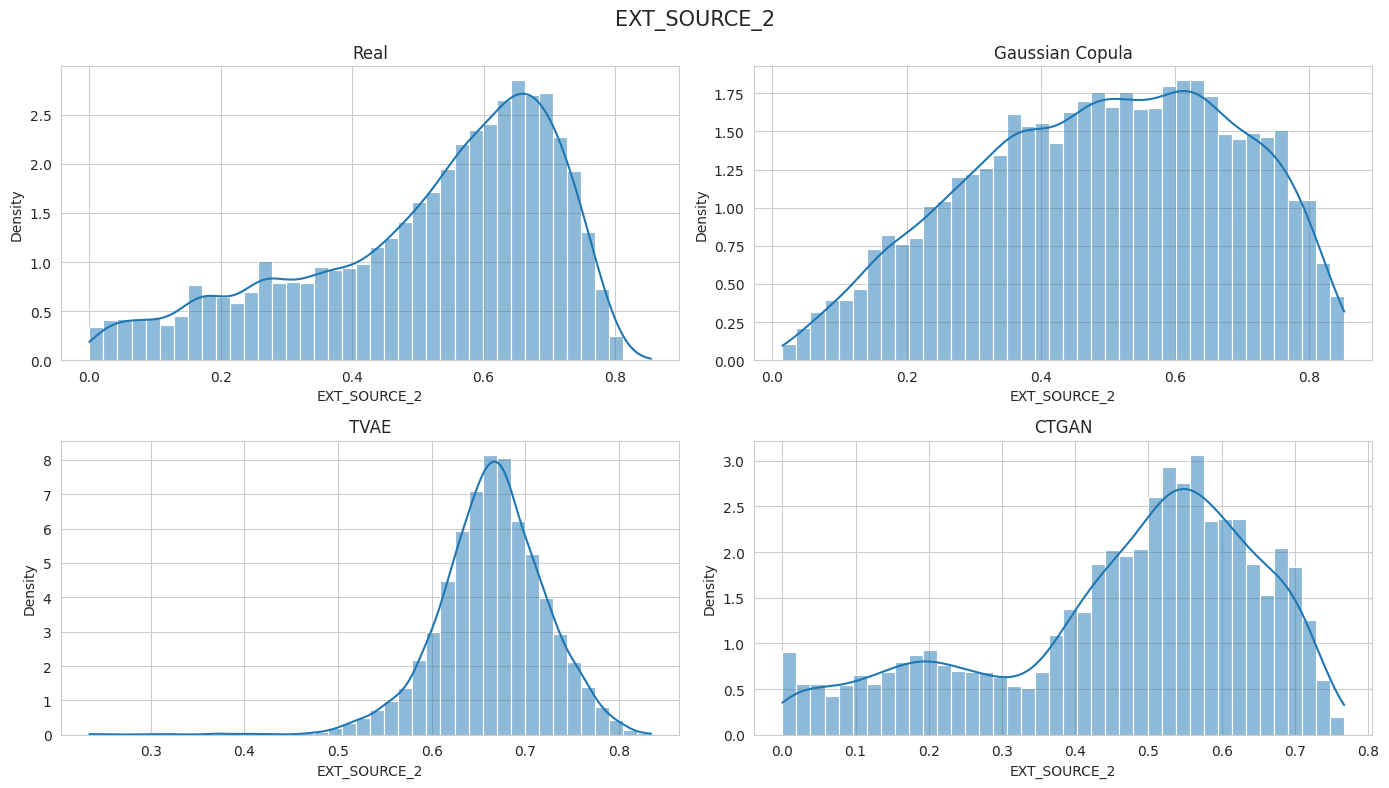

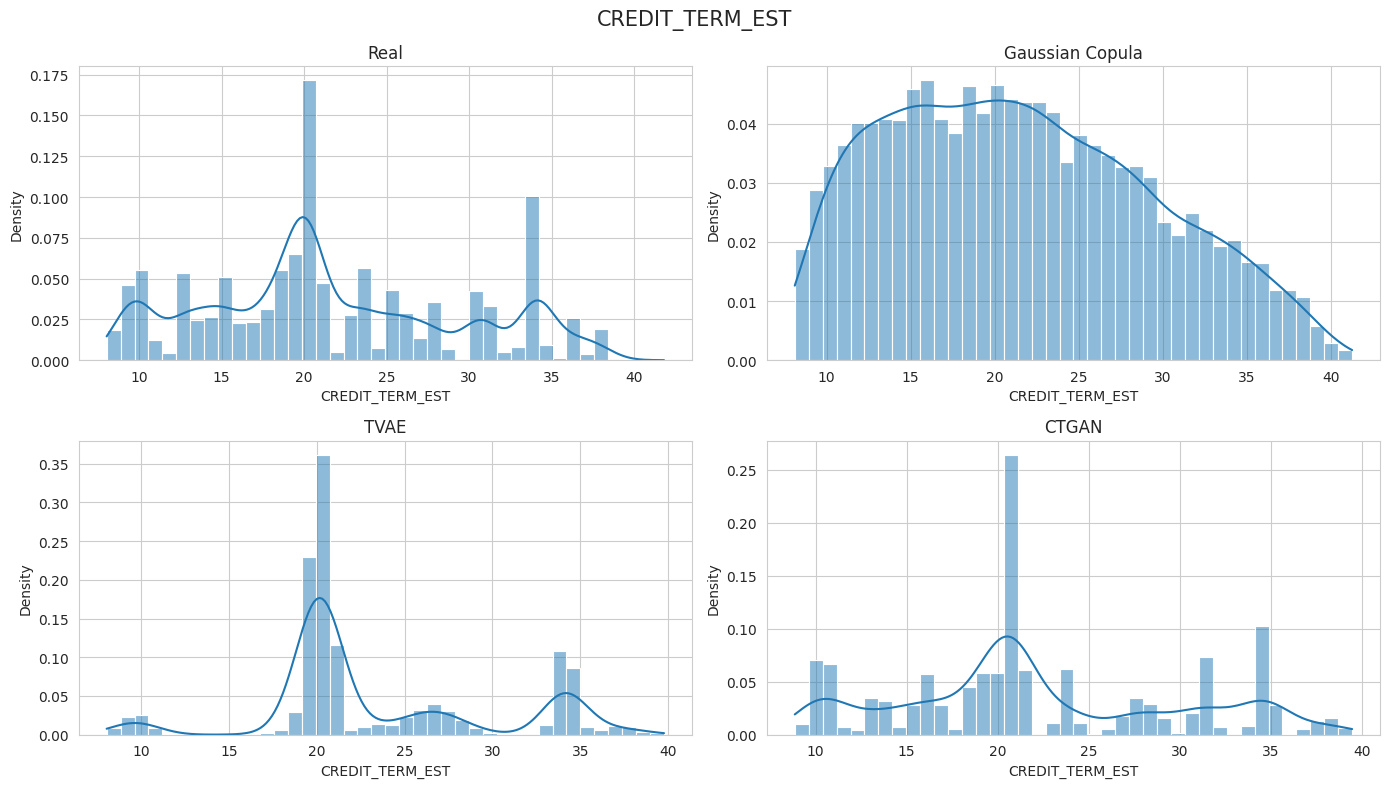

In [ ]:
#mostrar todas las variables
for variable in variables_plot:

    comparar_distribucion(variable)

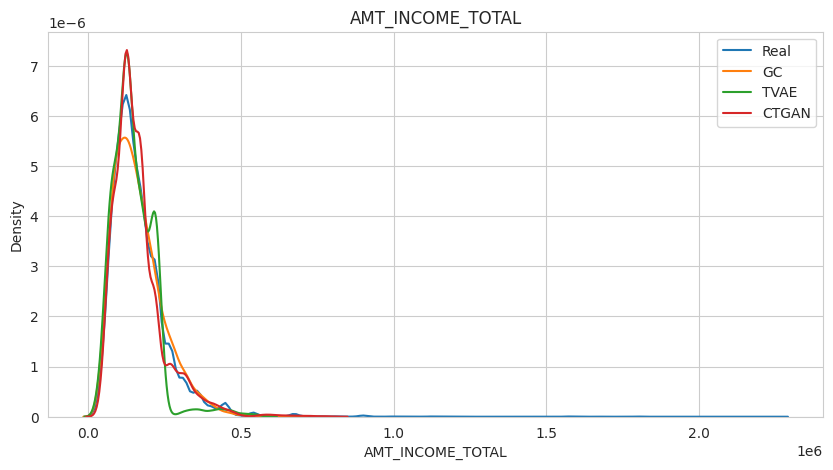

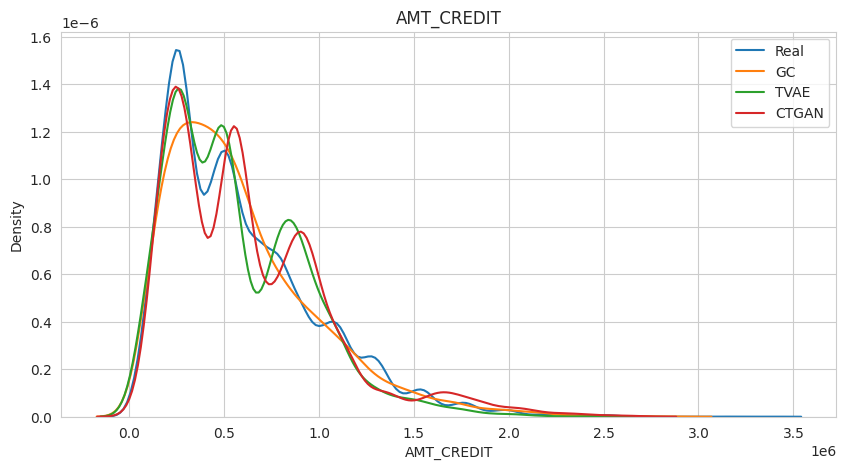

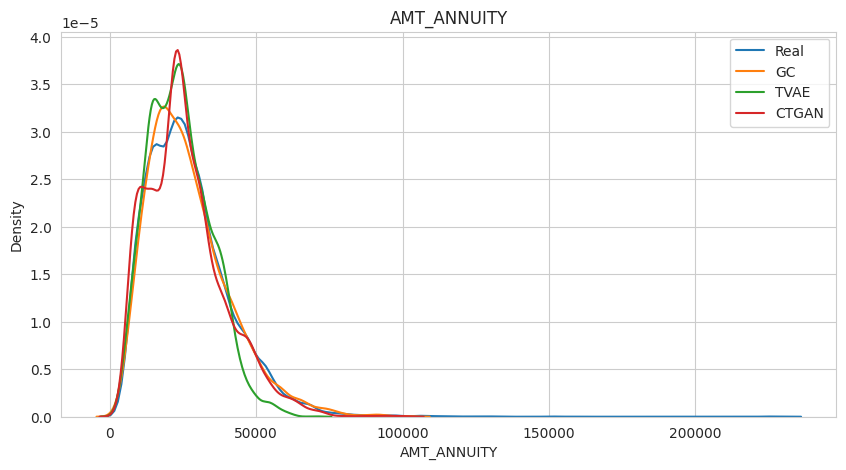

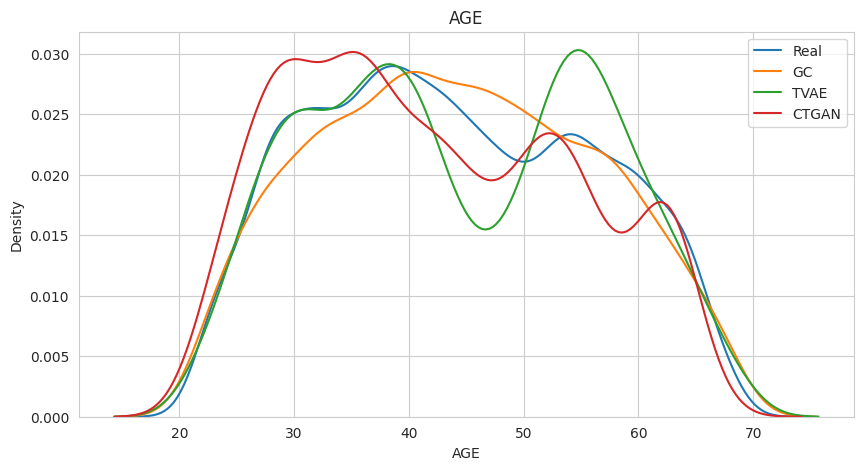

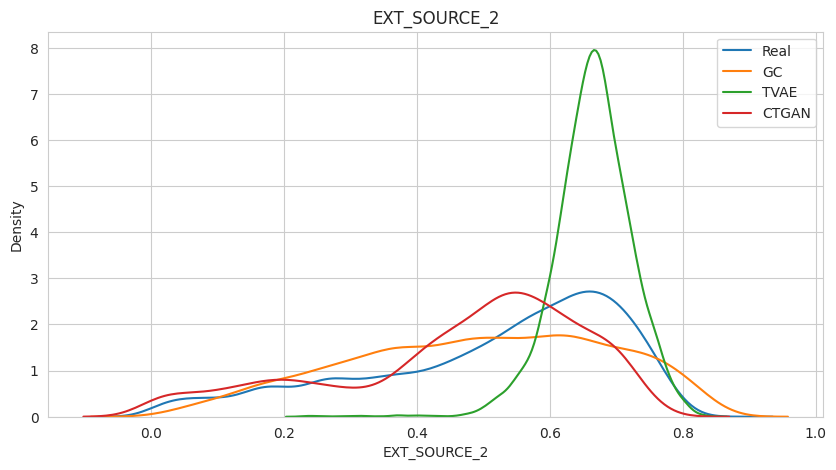

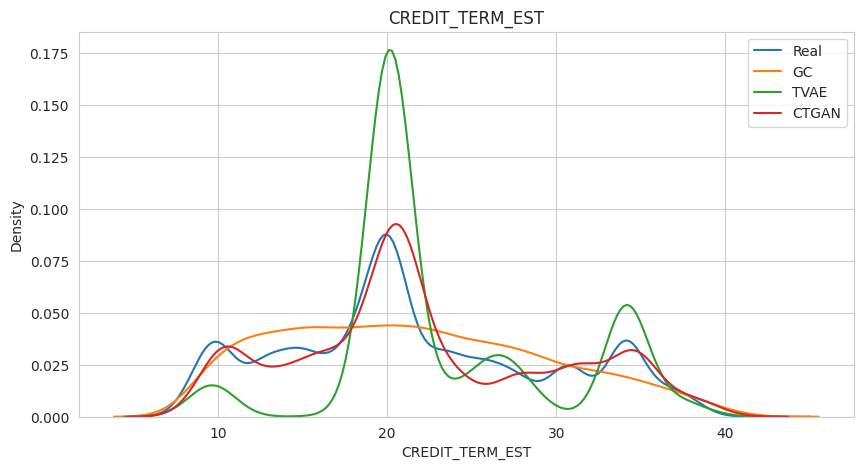

In [ ]:
# Si deseas que la comparación sea aún más clara, puedes superponer las curvas de densidad de los cuatro datasets en una sola gráfica por variable.
def comparar_kde(variable):

    plt.figure(figsize=(10,5))

    sns.kdeplot(df_experiment[variable], label="Real")
    sns.kdeplot(gc_sample[variable], label="GC")
    sns.kdeplot(df_tvae_sample[variable], label="TVAE")
    sns.kdeplot(df_ctgan_sample[variable], label="CTGAN")

    plt.title(variable)

    plt.legend()

    plt.show()

for variable in variables_plot:

    comparar_kde(variable)

#### 3.5.7 Ranking global de desempeño

Aquí reuniremos todas las métricas que hemos calculado.

In [ ]:
#Resumen
ranking = pd.DataFrame({

    "Modelo":[
        "Gaussian Copula",
        "TVAE",
        "CTGAN"
    ],

    "Error Estadísticas":[
        estadisticas.loc[
            estadisticas["Modelo"]=="Gaussian Copula",
            "Error Medio (%)"
        ].values[0],

        estadisticas.loc[
            estadisticas["Modelo"]=="TVAE",
            "Error Medio (%)"
        ].values[0],

        estadisticas.loc[
            estadisticas["Modelo"]=="CTGAN",
            "Error Medio (%)"
        ].values[0],
    ],

    "Correlation MAE":[
        correlaciones.loc[
            correlaciones["Modelo"]=="Gaussian Copula",
            "Correlation MAE"
        ].values[0],

        correlaciones.loc[
            correlaciones["Modelo"]=="TVAE",
            "Correlation MAE"
        ].values[0],

        correlaciones.loc[
            correlaciones["Modelo"]=="CTGAN",
            "Correlation MAE"
        ].values[0],
    ],

    "KS Medio":[
        ranking_dist.loc[
            ranking_dist["Modelo"]=="Gaussian Copula",
            "KS Medio"
        ].values[0],

        ranking_dist.loc[
            ranking_dist["Modelo"]=="TVAE",
            "KS Medio"
        ].values[0],

        ranking_dist.loc[
            ranking_dist["Modelo"]=="CTGAN",
            "KS Medio"
        ].values[0],
    ],

    "Wasserstein":[
        ranking_dist.loc[
            ranking_dist["Modelo"]=="Gaussian Copula",
            "Wasserstein Medio"
        ].values[0],

        ranking_dist.loc[
            ranking_dist["Modelo"]=="TVAE",
            "Wasserstein Medio"
        ].values[0],

        ranking_dist.loc[
            ranking_dist["Modelo"]=="CTGAN",
            "Wasserstein Medio"
        ].values[0],
    ]

})

ranking

,Modelo,Error Estadísticas,Correlation MAE,KS Medio,Wasserstein
0,Gaussian Copula,117.430844,0.029254,0.174426,281128.408162
1,TVAE,121.552870,0.079924,0.197802,283031.362316
2,CTGAN,120.719727,0.052596,0.149386,282211.669103


In [ ]:
#Ranking
ranking_final = ranking.copy()

ranking_final["Rank Estadísticas"] = ranking_final["Error Estadísticas"].rank(method="min")
ranking_final["Rank Correlación"] = ranking_final["Correlation MAE"].rank(method="min")
ranking_final["Rank KS"] = ranking_final["KS Medio"].rank(method="min")
ranking_final["Rank Wasserstein"] = ranking_final["Wasserstein"].rank(method="min")

ranking_final["Puntaje Total"] = (
    ranking_final["Rank Estadísticas"] +
    ranking_final["Rank Correlación"] +
    ranking_final["Rank KS"] +
    ranking_final["Rank Wasserstein"]
)

ranking_final = ranking_final.sort_values("Puntaje Total")

ranking_final

,Modelo,Error Estadísticas,Correlation MAE,KS Medio,Wasserstein,Rank Estadísticas,Rank Correlación,Rank KS,Rank Wasserstein,Puntaje Total
0,Gaussian Copula,117.430844,0.029254,0.174426,281128.408162,1.0,1.0,2.0,1.0,5.0
2,CTGAN,120.719727,0.052596,0.149386,282211.669103,2.0,2.0,1.0,2.0,7.0
1,TVAE,121.552870,0.079924,0.197802,283031.362316,3.0,3.0,3.0,3.0,12.0


#### 3.5.8 Comparación del tiempo de entrenamiento y generación

Objetivo

Comparar el costo computacional de cada sintetizador considerando:

Tiempo de entrenamiento
Tiempo de generación
Calidad obtenida

Esto permitirá justificar que la selección del modelo no depende únicamente de la calidad estadística, sino también de la eficiencia.

In [ ]:
#Durante el entranmiento guardamos
tiempo_gc
tiempo_tvae
tiempo_ctgan

610.5826835632324

In [ ]:
#Importciones
import time

In [ ]:
#GC
inicio = time.time()

gc_sample = gc_synthesizer.sample(5000)

tiempo_generacion_gc = time.time() - inicio

print(f"Tiempo generación GC: {tiempo_generacion_gc:.2f} segundos")

Tiempo generación GC: 1.17 segundos


In [ ]:
#TVAE
inicio = time.time()

df_tvae_sample = tvae_synthesizer.sample(5000)

tiempo_generacion_tvae = time.time() - inicio

print(f"Tiempo generación TVAE: {tiempo_generacion_tvae:.2f} segundos")

Tiempo generación TVAE: 0.71 segundos


In [ ]:
#CTGAN
inicio = time.time()

df_ctgan_sample = ctgan_synthesizer.sample(5000)

tiempo_generacion_ctgan = time.time() - inicio

print(f"Tiempo generación CTGAN: {tiempo_generacion_ctgan:.2f} segundos")

Tiempo generación CTGAN: 1.01 segundos


In [ ]:
#Tabla comparativa
import pandas as pd

tiempos = pd.DataFrame({

    "Modelo":[
        "Gaussian Copula",
        "TVAE",
        "CTGAN"
    ],

    "Entrenamiento (s)":[
        tiempo_gc,
        tiempo_tvae,
        tiempo_ctgan
    ],

    "Generación (s)":[
        tiempo_generacion_gc,
        tiempo_generacion_tvae,
        tiempo_generacion_ctgan
    ]

})

tiempos

,Modelo,Entrenamiento (s),Generación (s)
0,Gaussian Copula,27.986482,1.173370
1,TVAE,209.717454,0.707992
2,CTGAN,610.582684,1.008595


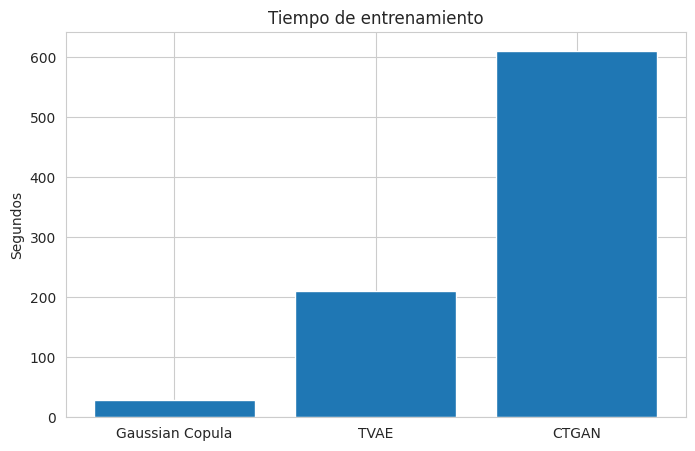

In [ ]:
#Comparacion visual
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    tiempos["Modelo"],
    tiempos["Entrenamiento (s)"]
)

plt.ylabel("Segundos")

plt.title("Tiempo de entrenamiento")

plt.show()

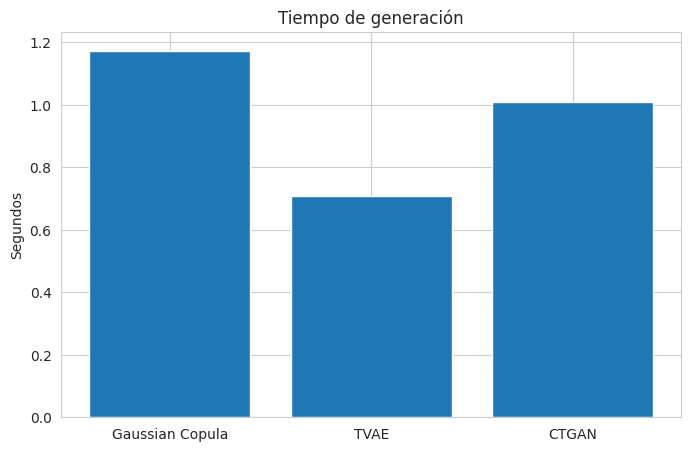

In [ ]:
#Grafica para la generacion
plt.figure(figsize=(8,5))

plt.bar(
    tiempos["Modelo"],
    tiempos["Generación (s)"]
)

plt.ylabel("Segundos")

plt.title("Tiempo de generación")

plt.show()

In [ ]:
ranking_final

,Modelo,Error Estadísticas,Correlation MAE,KS Medio,Wasserstein,Rank Estadísticas,Rank Correlación,Rank KS,Rank Wasserstein,Puntaje Total
0,Gaussian Copula,117.430844,0.029254,0.174426,281128.408162,1.0,1.0,2.0,1.0,5.0
2,CTGAN,120.719727,0.052596,0.149386,282211.669103,2.0,2.0,1.0,2.0,7.0
1,TVAE,121.552870,0.079924,0.197802,283031.362316,3.0,3.0,3.0,3.0,12.0


Conclusión de la comparación experimental

• Gaussian Copula obtuvo el mejor desempeño global.

• CTGAN presentó el mejor KS medio, indicando una buena preservación de las distribuciones.

• TVAE mostró resultados competitivos, aunque inferiores en la mayoría de métricas.

• En conjunto, Gaussian Copula fue seleccionado como el sintetizador con mejor equilibrio entre preservación estadística y estructura de los datos.

### 3.6 Selección del sintetizador definitivo

**5.6 Selección del sintetizador definitivo**

A partir de la evaluación experimental realizada sobre una muestra estratificada de 20 000 observaciones, se seleccionó el modelo que obtuvo el mejor equilibrio entre la conservación de las propiedades estadísticas, la estructura de correlaciones y las distribuciones de las variables.

El sintetizador seleccionado será posteriormente entrenado utilizando el conjunto completo de datos reales con el objetivo de generar el dataset sintético definitivo que será utilizado en la etapa de modelado predictivo.

In [ ]:
ranking_final

,Modelo,Error Estadísticas,Correlation MAE,KS Medio,Wasserstein,Rank Estadísticas,Rank Correlación,Rank KS,Rank Wasserstein,Puntaje Total
0,Gaussian Copula,117.430844,0.029254,0.174426,281128.408162,1.0,1.0,2.0,1.0,5.0
2,CTGAN,120.719727,0.052596,0.149386,282211.669103,2.0,2.0,1.0,2.0,7.0
1,TVAE,121.552870,0.079924,0.197802,283031.362316,3.0,3.0,3.0,3.0,12.0


In [ ]:
#Seleccionar automaticamente el mejor modelo
mejor_modelo = ranking_final.iloc[0]["Modelo"]

print(f"Modelo seleccionado: {mejor_modelo}")

Modelo seleccionado: Gaussian Copula


**Justificación**

Gaussian Copula obtuvo el menor puntaje global durante la comparación experimental.

Su desempeño fue superior en:

- Conservación de estadísticas descriptivas.
- Conservación de correlaciones.
- Distancia Wasserstein.
- Rendimiento global.

Por ello fue seleccionado como el modelo encargado de generar el conjunto sintético definitivo.

### 3.7 Entrenamiento del sintetizador seleccionado con el dataset completo

#### 3.7.1 Preparación

**5.7 Entrenamiento del sintetizador seleccionado con el dataset completo**

Una vez identificado Gaussian Copula como el sintetizador con mejor desempeño global durante la comparación experimental, se procedió a entrenarlo utilizando el conjunto completo de datos reales.

Este entrenamiento permitirá generar el dataset sintético definitivo que será utilizado en la etapa de modelado predictivo.

In [ ]:
print("Número de registros:", len(df_real))
print("Número de variables:", df_real.shape[1])

Número de registros: 307507
Número de variables: 41


#### 3.7.2 Entrenamiento definitivo

In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer
import time

In [ ]:
#Como el metadata ya lo construimos anteriormente, simplemente reutilizamos el mismo.
gc_final = GaussianCopulaSynthesizer(
    metadata=metadata
)

In [ ]:
inicio = time.time()

gc_final.fit(df_real)

tiempo_final = time.time() - inicio

print(f"Tiempo entrenamiento: {tiempo_final:.2f} segundos")

Tiempo entrenamiento: 312.76 segundos


In [ ]:
#Guardar el modelo entrenado (muy recomendable)
#import joblib
ruta_modelo = "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/03_Syntetic_Data/gaussian_copula_final.pkl"

#joblib.dump(gc_final, ruta_modelo)

#print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [ ]:
#Reuzar el modelo desde drive
#gc_final = joblib.load(ruta_modelo)

### 3.8 Generación del dataset sintético definitivo

**5.8 Generación del dataset sintético definitivo**

Una vez entrenado el sintetizador seleccionado utilizando el conjunto completo de datos reales, se procedió a generar el dataset sintético definitivo.

Con el objetivo de facilitar una comparación directa entre los modelos entrenados con datos reales y sintéticos, el número de registros generados fue igual al del conjunto original.

#### 3.8.1 Generación

In [ ]:
n_registros = len(df_real)

print(f"Registros a generar: {n_registros:,}")

Registros a generar: 307,507


In [ ]:
#Genramos el dataset
df_sintetico = gc_final.sample(num_rows=n_registros)

In [ ]:
#Verificamos
print(df_sintetico.shape)

df_sintetico.head()

(307507, 41)


,TARGET,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_REQ_CREDIT_BUREAU_YEAR,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,CODE_GENDER,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS,NAME_EDUCATION_TYPE,NAME_HOUSING_TYPE,DAYS_EMPLOYED,NAME_INCOME_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,OWN_CAR_AGE,FLAG_OWN_REALTY,NAME_CONTRACT_TYPE,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,AGE,EMPLOYMENT_YEARS,HAS_CAR_AGE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_FAMILY,CHILDREN_RATIO,CREDIT_TERM_EST
0,0,13460034,129038.073,905040.8,31639.3,880472.1,0.0,3.0,0.0,3.0,0.0,0.341177,0.618428,0.213495,-18782,F,0,1.0,Married,Secondary / secondary special,House / apartment,-4498.0,Pensioner,Laborers,Government,N,7.0,Y,Cash loans,Unaccompanied,SUNDAY,10,51.4,13.1,0,6.025643,0.230792,0.971815,87990.940881,0.381383,27.203096
1,0,2493192,179026.727,791257.9,42762.9,700492.5,0.0,1.0,0.0,1.0,0.0,0.472601,0.239948,0.314533,-10860,M,0,2.0,Single / not married,Secondary / secondary special,House / apartment,-189.0,Working,Security staff,Industry: type 7,N,22.0,N,Cash loans,Unaccompanied,SUNDAY,15,29.8,0.5,1,5.362969,0.264972,1.120786,61777.845624,0.430581,18.449801
2,0,8589238,119030.447,925441.2,50297.8,987274.0,0.0,0.0,0.0,0.0,0.0,0.639657,0.536523,0.495505,-23774,F,0,2.0,Married,Secondary / secondary special,House / apartment,-5589.0,Working,Laborers,XNA,N,13.0,Y,Cash loans,Unaccompanied,WEDNESDAY,12,65.1,14.9,1,7.001423,0.385934,0.930154,51113.813738,0.469557,16.170933
3,0,10313411,111302.212,1041603.8,16648.9,996555.8,0.0,0.0,0.0,0.0,0.0,0.484367,0.582709,0.495488,-8061,F,0,1.0,Married,Secondary / secondary special,Co-op apartment,-2576.0,Working,Drivers,Trade: type 6,N,9.0,Y,Revolving loans,Unaccompanied,MONDAY,10,22.1,7.1,0,8.212393,0.156226,1.101708,69476.237772,0.374441,54.741353
4,1,2525172,268567.454,1578403.5,39788.2,1312277.4,1.0,3.0,0.0,3.0,0.0,0.595002,0.649981,0.720716,-12252,M,0,1.0,Married,Secondary / secondary special,House / apartment,-2754.0,Working,High skill tech staff,Hotel,Y,11.0,Y,Cash loans,Unaccompanied,TUESDAY,15,33.5,7.9,0,7.491295,0.161916,1.339803,161812.661156,0.412867,46.652125


#### 3.8.2 Verificación rápida

In [ ]:
print(df_sintetico.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307507 entries, 0 to 307506
Data columns (total 41 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      307507 non-null  int64  
 1   SK_ID_CURR                  307507 non-null  int64  
 2   AMT_INCOME_TOTAL            307507 non-null  float64
 3   AMT_CREDIT                  307507 non-null  float64
 4   AMT_ANNUITY                 307507 non-null  float64
 5   AMT_GOODS_PRICE             307507 non-null  float64
 6   AMT_REQ_CREDIT_BUREAU_YEAR  307507 non-null  float64
 7   OBS_30_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 8   DEF_30_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 9   OBS_60_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 10  DEF_60_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 11  EXT_SOURCE_1                307507 non-null  float64
 12  EXT_SOURCE_2                307507 non-null  float64
 13  EXT_SOURCE_3  

In [ ]:
print(df_real.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307507 entries, 0 to 307506
Data columns (total 41 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      307507 non-null  int64  
 1   SK_ID_CURR                  307507 non-null  int64  
 2   AMT_INCOME_TOTAL            307507 non-null  float64
 3   AMT_CREDIT                  307507 non-null  float64
 4   AMT_ANNUITY                 307507 non-null  float64
 5   AMT_GOODS_PRICE             307507 non-null  float64
 6   AMT_REQ_CREDIT_BUREAU_YEAR  307507 non-null  float64
 7   OBS_30_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 8   DEF_30_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 9   OBS_60_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 10  DEF_60_CNT_SOCIAL_CIRCLE    307507 non-null  float64
 11  EXT_SOURCE_1                307507 non-null  float64
 12  EXT_SOURCE_2                307507 non-null  float64
 13  EXT_SOURCE_3  

In [ ]:
#Verificamos nulos:
df_sintetico.isnull().sum().sort_values(ascending=False).head(10)

,0
TARGET,0
SK_ID_CURR,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,0
AMT_GOODS_PRICE,0
AMT_REQ_CREDIT_BUREAU_YEAR,0
OBS_30_CNT_SOCIAL_CIRCLE,0
DEF_30_CNT_SOCIAL_CIRCLE,0
OBS_60_CNT_SOCIAL_CIRCLE,0


In [ ]:
#Verificacion de TARGET
df_sintetico["TARGET"].value_counts(normalize=True)

,proportion
TARGET,
0,0.918594
1,0.081406


In [ ]:
#Comparacion con dataset real
comparacion = pd.DataFrame({

    "Real (%)": df_real["TARGET"].value_counts(normalize=True),

    "Sintético (%)": df_sintetico["TARGET"].value_counts(normalize=True)

})

comparacion

,Real (%),Sintético (%)
TARGET,,
0,0.91927,0.918594
1,0.08073,0.081406


#### 3.8.3 Estadísticas generales

In [ ]:
pd.DataFrame({

    "Real": df_real.describe().loc["mean"],

    "Sintético": df_sintetico.describe().loc["mean"]

}).head(15)

,Real,Sintético
TARGET,0.080730,8.140628e-02
SK_ID_CURR,278181.527256,8.389362e+06
AMT_INCOME_TOTAL,168797.685779,1.688999e+05
AMT_CREDIT,599028.596733,5.991724e+05
AMT_ANNUITY,27108.580714,2.711096e+04
AMT_GOODS_PRICE,538317.809016,5.384450e+05
AMT_REQ_CREDIT_BUREAU_YEAR,1.778441,5.387422e-01
OBS_30_CNT_SOCIAL_CIRCLE,1.417486,1.685233e+00
DEF_30_CNT_SOCIAL_CIRCLE,0.142930,1.432845e-01
OBS_60_CNT_SOCIAL_CIRCLE,1.400589,1.645104e+00


#### 3.8.4 Comparación del tamaño

In [ ]:
print("Dataset real")
print(df_real.shape)

print()

print("Dataset sintético")
print(df_sintetico.shape)

Dataset real
(307507, 41)

Dataset sintético
(307507, 41)


#### 3.8.5 Exportación del dataset sintético

In [ ]:
#df_sintetico.to_csv("/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/03_Syntetic_Data/home_credit_synthetic_gc.csv", index=False)